## Setup for EDA and time series 

In [2]:
#pip install xgboost

In [3]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# this for time series
#import statsmodels.formula.api as smf
#from statsmodels.tsa.seasonal import seasonal_decompose
#from scipy.ndimage import gaussian_filter
#from calendar import monthrange
#from calendar import month_name
#from sklearn.metrics import mean_squared_error
#from math import sqrt
#from statsmodels.tsa.stattools import adfuller,kpss
#from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.arima_model import ARIMA
#from statsmodels.graphics.tsaplots import plot_pacf
#from pmdarima.arima import auto_arima
#import statsmodels.graphics.tsaplots as tsaplot
#from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing

#import tensorflow as tf
#from keras.models import Sequential
#from keras.layers import LSTM, Dense

#from keras.callbacks import EarlyStopping
#from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time
import matplotlib.dates as mdates   
from tensorflow.keras.regularizers import l1, l2



In [4]:
#from statsmodels.tsa.stattools import adfuller
#!pip install pmdarima --quiet
#import pmdarima as pm


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 
- df_dt is final dataframe for XG Boost regressor (only contain the 'datatime' and  'target' features)

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [5]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [6]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [7]:
#res_df.dtypes

In [8]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [9]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [10]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [11]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [12]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [13]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [14]:
data_df_gwh = data_df_mwh.copy()

In [15]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [16]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [17]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [18]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [19]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [20]:

data_df= data_df_gwh.copy()

In [21]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [22]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [23]:
##data_df.columns

In [24]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [25]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files

main_0  = 'Total_energy_generation_gwh' # This is only for energy
title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy

#main_0  = 'Solar_gwh' # for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Total energy generation in GWh
Total energy generation(GWh)


### Here we set the function for line plot  

In [26]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



In [27]:

def average_lineplot_no_group_eng(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average total energy generation in Germany by month', ylabel= 'Total energy generation energy (GWh)');
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()


def average_lineplot_no_group_sol(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average solar energy generation in Germany by month', ylabel='Solar energy generation (GWh)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()

def average_lineplot_no_group_ren(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average other renewable energy generation in Germany by month', ylabel='Other renewable energy generation (GWh)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()   


#target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh'



In [28]:
#average_lineplot_no_group_ren(df=data_df, y='Total_other_renewable_gwh', x="Date", time='Year')

In [29]:
#average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Year')

In [30]:
#average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Year')

In [31]:
'Total_energy_generation_gwh'
#average_lineplot_no_group_eng(df=data_df, y= 'Total_energy_generation_gwh', x="Date", time='Year')
#average_lineplot_no_group_eng(df=data_df, y= target, x="Date", time='Year')

'Total_energy_generation_gwh'

In [32]:
#average_lineplot_no_group_ren(df=data_df, y='Total_other_renewable_gwh', x="Date", time='Month')
#average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Month')
#average_lineplot_no_group_eng(df=data_df, y= 'Total_energy_generation_gwh', x="Date", time='Month')

In [33]:
#average_lineplot_no_group_eng(df=data_df, y= target, x="Date", time='Year')

In [34]:
## Energy development over year (time)
#fig, ax = plt.subplots()
#sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
#ax.set(title=title_main, ylabel= ylable_target);

In [35]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [36]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [37]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

In [38]:
#average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [39]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [40]:
daily_data_df, daily_data_df.columns, data_df.columns

(            Year  Month  Day  Dayofyear  Hour  Total_energy_generation_gwh
 Date                                                                      
 2015-01-01  2015      1    1          1     0                     51.45925
 2015-01-01  2015      1    1          1     1                     49.98825
 2015-01-01  2015      1    1          1     2                     49.26525
 2015-01-01  2015      1    1          1     3                     48.53800
 2015-01-01  2015      1    1          1     4                     48.63000
 ...          ...    ...  ...        ...   ...                          ...
 2023-07-17  2023      7   17        198    18                     55.58000
 2023-07-17  2023      7   17        198    19                     50.83350
 2023-07-17  2023      7   17        198    20                     46.67225
 2023-07-17  2023      7   17        198    21                     42.74150
 2023-07-17  2023      7   17        198    22                     19.82700
 
 [74871 ro

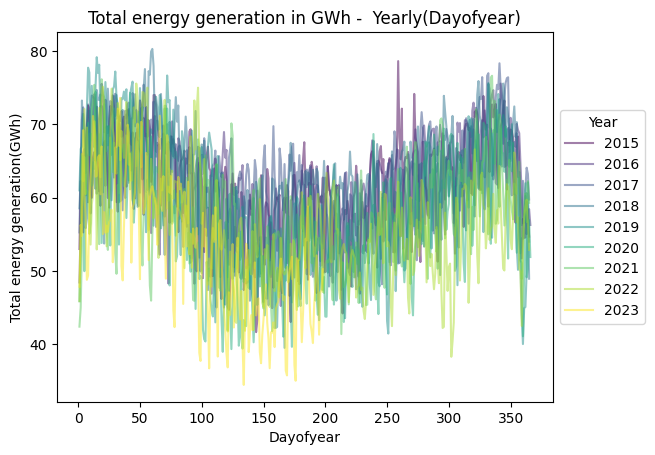

In [41]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [42]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [43]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

In [44]:
#data_df.columns

In [45]:
df_c = data_df.copy()

In [46]:
#df_c.columns

In [47]:
def combine_date_and_time(df, date_column='Date', time_column='Hour', target_column=target):
    # Convert 'Date' column to datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Combine 'Date' and 'Hour' columns to create the 'Datetime' column
    df['Datetime'] = df.apply(lambda row: row[date_column] + pd.Timedelta(hours=row[time_column]), axis=1)
    
    # Select the desired columns for the final DataFrame
    df_result  = df[['Datetime', target_column]]
    
    return df_result

In [48]:
df_dt = combine_date_and_time(df_c, date_column='Date', time_column='Hour', target_column=target)

#### I need to write a function to include seasonality and trend information of data 

In [49]:
# Rolling mean
# window =
#df_dt[target]=data_df[target].rolling(window=365).mean() 
#df_dt = df_dt.dropna() #df_dt = df_dt.dropna(how='all')#(axis=0)
#df_dt = df_dt.dropna(axis=0)
# Reset index after drop
#df_dt=df_dt.dropna().reset_index(drop=True)
#df_dt.head()

In [50]:
df_dt.columns

Index(['Datetime', 'Total_energy_generation_gwh'], dtype='object')

In [51]:
df_dt.head()

,Datetime,Total_energy_generation_gwh
0,2015-01-01 00:00:00,51.45925
1,2015-01-01 01:00:00,49.98825
2,2015-01-01 02:00:00,49.26525
3,2015-01-01 03:00:00,48.53800
4,2015-01-01 04:00:00,48.63000


<Axes: xlabel='Datetime'>

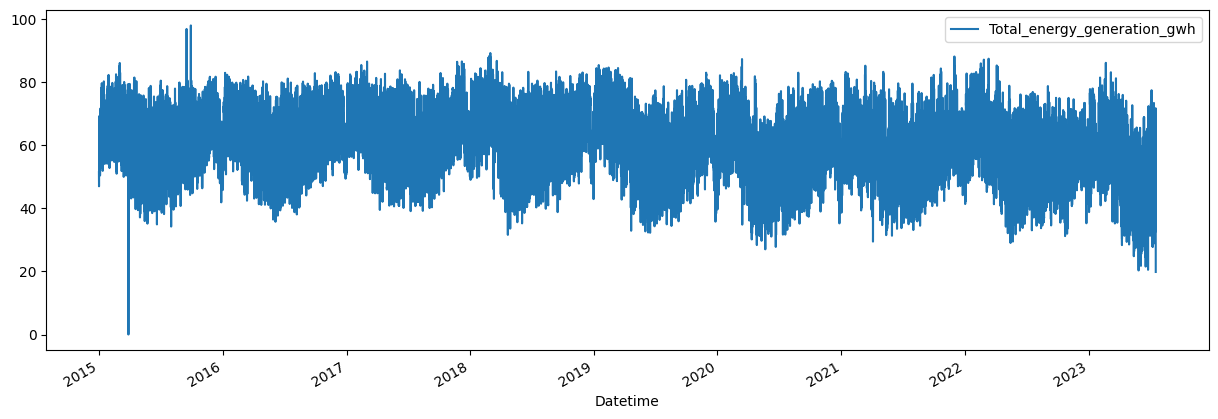

In [52]:

#df_c = data_df.copy()
#df_c = data_df[['Date',  target]]
df_dt = df_dt.set_index('Datetime')
df_dt.plot(style = '-', figsize = (15,5), color='#1f76b4')

In [53]:
#df_dt.loc[(df_dt.index > '2023-01-01') & (df_dt.index < '2023-12-01') ].plot(figsize=(15,5), ylabel=ylable_target, title= 'Data of last year', label = '2023 data')
#ax.legend(['2023 data'])
#plt.show()

In [54]:
def create_features(df):
    """
    create time series features based on time series index 
    """
    df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
   # df['Week'] = df.index.week
    df['Day'] = df.index.day
    #df['Dayofyear'] = df.index.dayofyear
    return df
#df_dt = create_features(df_dt)
#df_dt.head()

In [55]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Hour', y =target)
#ax.set_title( title_main + '' + ' ' 'by hour')
#ax.set_ylabel(ylable_target)

In [56]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Month', y =target)
#ax.set_title(title_main + '' + ' ' 'by month')
#ax.set_ylabel(ylable_target)

In [57]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Day', y =target)
#ax.set_title(title_main + '' + ' ' 'by day')
#ax.set_ylabel(ylable_target)

In [58]:
dfs = data_df[['Date', target]]

In [59]:
df_dt.head()
#df_dt['Datetime'] = pd.to_datetime(df_dt['Datetime'])
#df_dt.set_index('Datetime', inplace=True)

,Total_energy_generation_gwh
Datetime,
2015-01-01 00:00:00,51.45925
2015-01-01 01:00:00,49.98825
2015-01-01 02:00:00,49.26525
2015-01-01 03:00:00,48.53800
2015-01-01 04:00:00,48.63000


In [60]:
dfs.head()

,Date,Total_energy_generation_gwh
0,2015-01-01,51.45925
1,2015-01-01,49.98825
2,2015-01-01,49.26525
3,2015-01-01,48.53800
4,2015-01-01,48.63000


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_93947/1283765561.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dfs[target])


Text(0.5, 1.0, 'Energy Distribution')

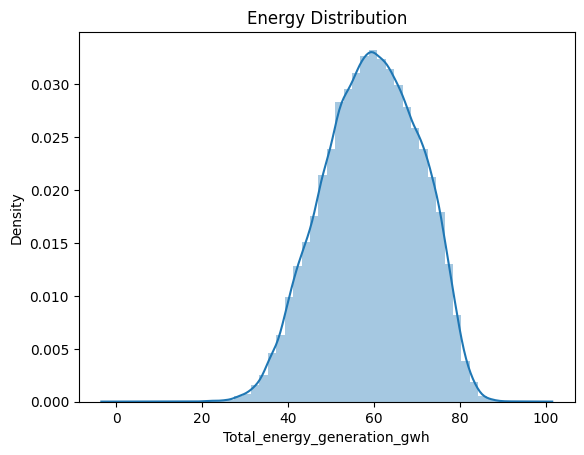

In [60]:
sns.distplot(dfs[target])
plt.title("Energy Distribution")
#sns.distplot(dfs['Solar_gwh'])
#plt.title("Solae Energy Distribution")

#### Univariate LSTM (SGD+earlystopping)

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_93947/3648283666.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/50
6738/6738 - 28s - loss: 0.0270 - val_loss: 0.0301 - 28s/epoch - 4ms/step
Epoch 2/50
6738/6738 - 24s - loss: 0.0134 - val_loss: 0.0149 - 24s/epoch - 4ms/step
Epoch 3/50
6738/6738 - 24s - loss: 0.0087 - val_loss: 0.0111 - 24s/epoch - 4ms/step
Epoch 4/50
6738/6738 - 24s - loss: 0.0066 - val_loss: 0.0085 - 24s/epoch - 4ms/step
Epoch 5/50
6738/6738 - 24s - loss: 0.0052 - val_loss: 0.0067 - 24s/epoch - 4ms/step
Epoch 6/50
6738/6738 - 24s - loss: 0.0043 - val_loss: 0.0057 - 24s/epoch - 4ms/step
Epoch 7/50
6738/6738 - 24s - loss: 0.0038 - val_loss: 0.0049 - 24s/epoch - 4ms/step
Epoch 8/50
6738/6738 - 29s - loss: 0.0034 - val_loss: 0.0043 - 29s/epoch - 4ms/step
Epoch 9/50
6738/6738 - 26s - loss: 0.0032 - val_loss: 0.0041 - 26s/epoch - 4ms/step
Epoch 10/50
6738/6738 - 27s - loss: 0.0030 - val_loss: 0.0037 - 27s/epoch - 4ms/step
Epoch 11/50
6738/6738 - 18s - loss: 0.0029 - val_loss: 0.0034 - 18s/epoch - 3ms/step
Epoch 12/50
6738/6738 - 18s - loss: 0.0027 - val_loss: 0.0032 - 18s/epoch 

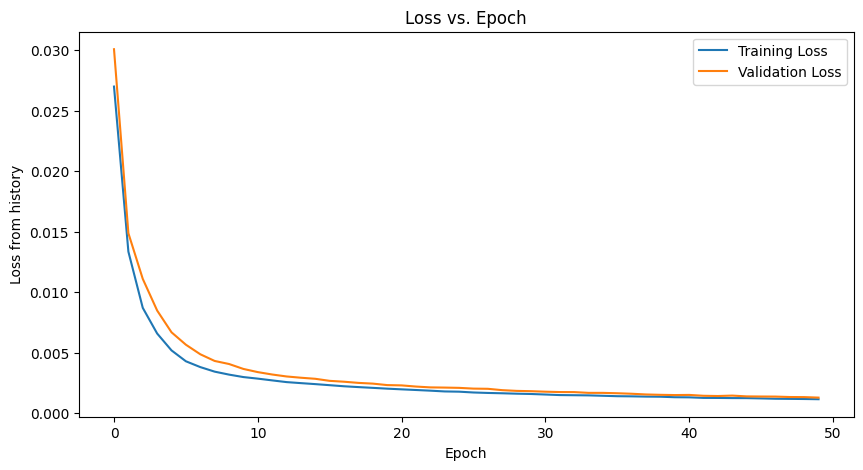

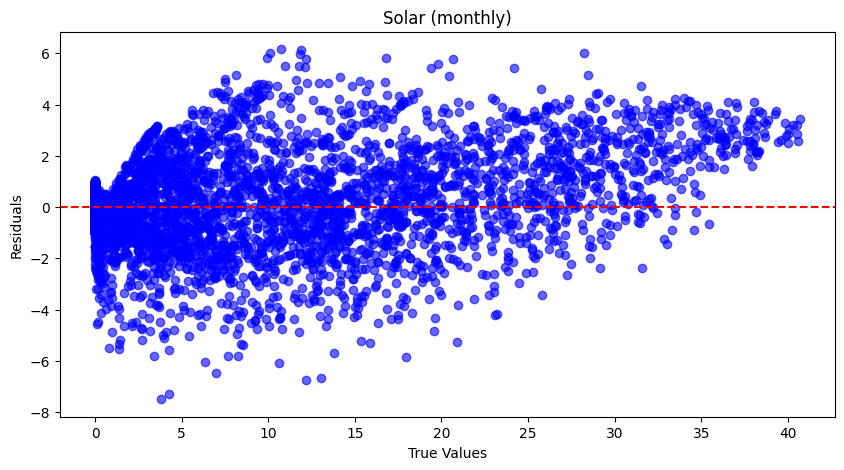

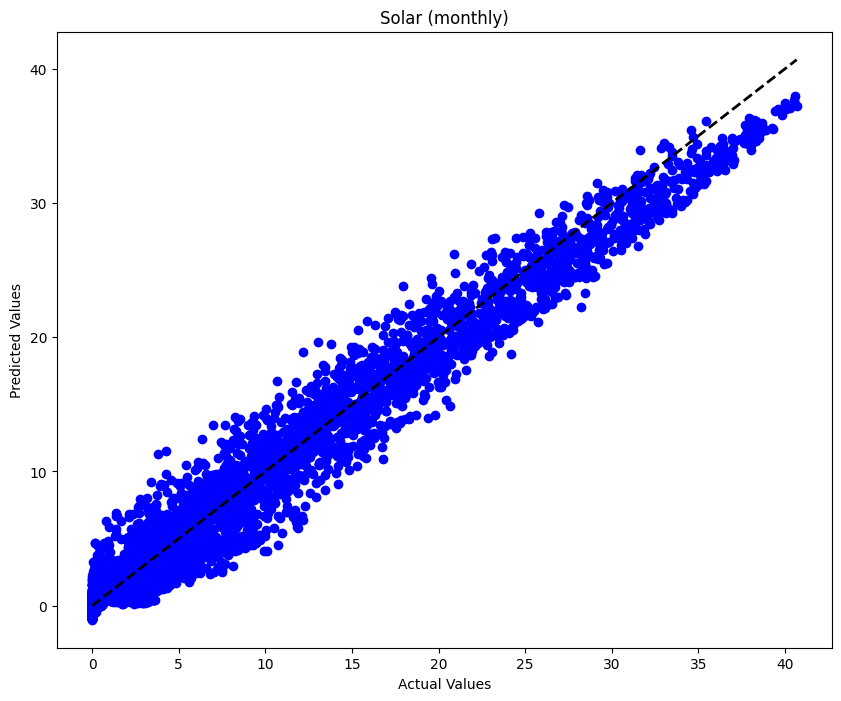

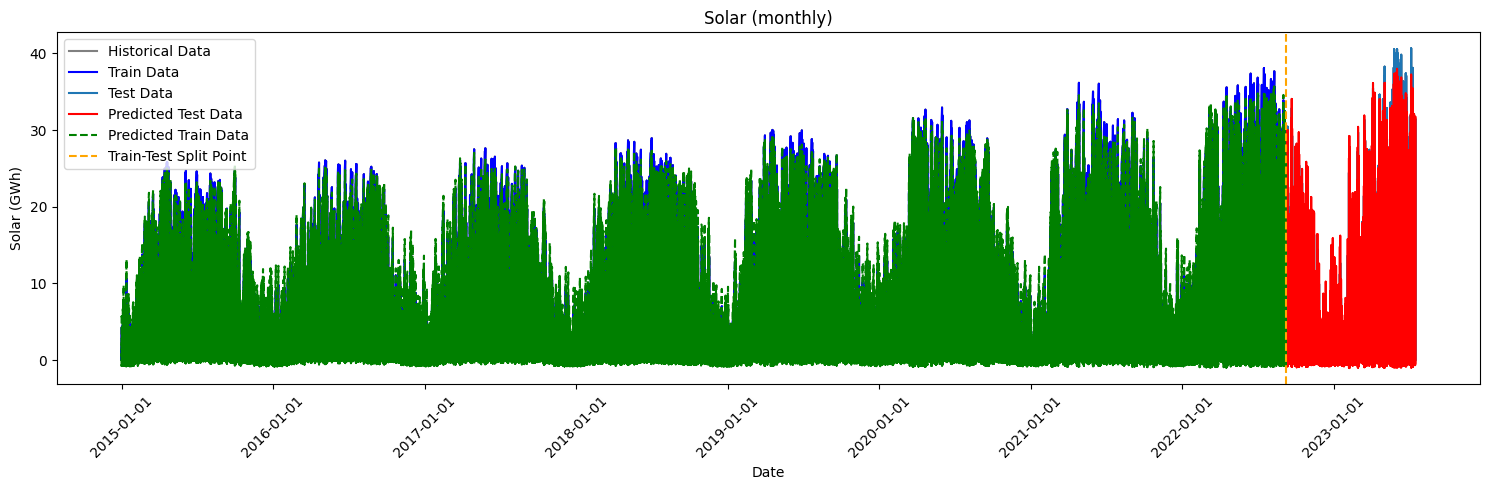

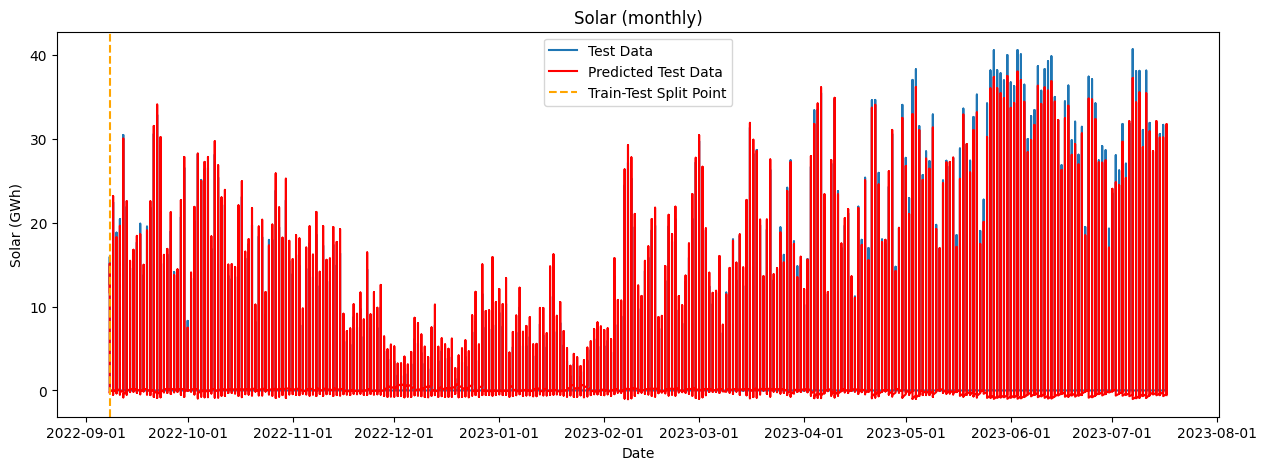

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 12, 64)            16896     
                                                                 
 dropout_3 (Dropout)         (None, 12, 64)            0         
                                                                 
 lstm_7 (LSTM)               (None, 32)                12416     
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


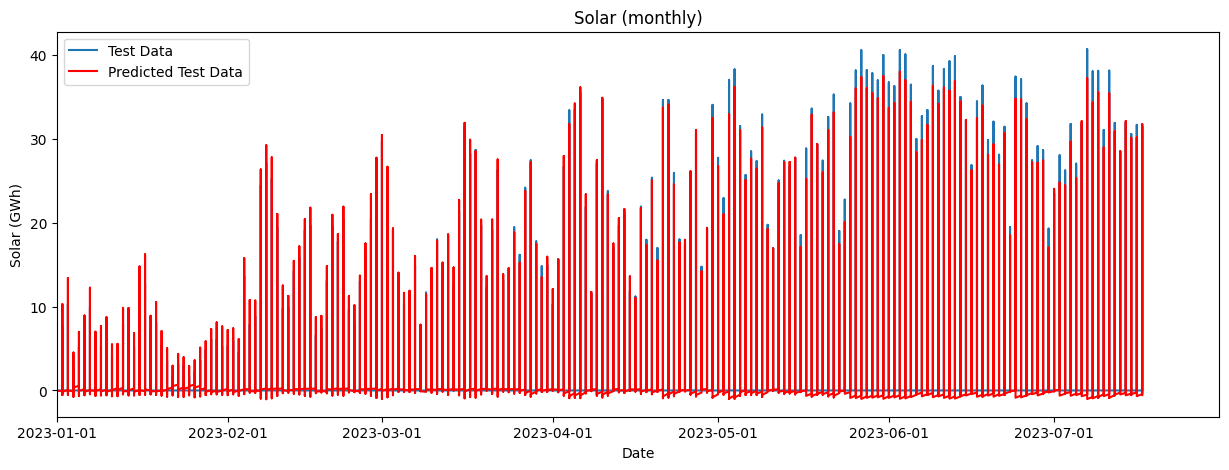

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (67380, 12, 1) (7499, 12, 1) (67380, 1) (7499, 1) (74867, 12, 1) (74867, 1) (74879, 1)


In [66]:
from keras.optimizers import SGD
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.9)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

    #optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.99999)
    optimizer = SGD(learning_rate=0.001, momentum=0.9)
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(Dropout(0.2))  # Adding dropout regularization to the first LSTM layer
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer= optimizer)
    ##
    ##
    # Adding early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=10,
                        validation_data=(X_test_lstm, y_test_lstm),
                        callbacks=[early_stopping], verbose=2)

    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)
    return model
lookback=12
results = lstm_model('Solar_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  


# Rest of the code, including lookback and calling lstm_model, remains unchanged.


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_93947/1764836328.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/50
5990/5990 - 27s - loss: 0.0295 - val_loss: 0.0518 - 27s/epoch - 4ms/step
Epoch 2/50
5990/5990 - 26s - loss: 0.0280 - val_loss: 0.0508 - 26s/epoch - 4ms/step
Epoch 3/50
5990/5990 - 28s - loss: 0.0274 - val_loss: 0.0490 - 28s/epoch - 5ms/step
Epoch 4/50
5990/5990 - 28s - loss: 0.0267 - val_loss: 0.0478 - 28s/epoch - 5ms/step
Epoch 5/50
5990/5990 - 29s - loss: 0.0261 - val_loss: 0.0468 - 29s/epoch - 5ms/step
Epoch 6/50
5990/5990 - 27s - loss: 0.0255 - val_loss: 0.0455 - 27s/epoch - 4ms/step
Epoch 7/50
5990/5990 - 26s - loss: 0.0248 - val_loss: 0.0439 - 26s/epoch - 4ms/step
Epoch 8/50
5990/5990 - 27s - loss: 0.0240 - val_loss: 0.0424 - 27s/epoch - 4ms/step
Epoch 9/50
5990/5990 - 27s - loss: 0.0232 - val_loss: 0.0412 - 27s/epoch - 4ms/step
Epoch 10/50
5990/5990 - 26s - loss: 0.0223 - val_loss: 0.0392 - 26s/epoch - 4ms/step
Epoch 11/50
5990/5990 - 27s - loss: 0.0212 - val_loss: 0.0371 - 27s/epoch - 4ms/step
Epoch 12/50
5990/5990 - 29s - loss: 0.0201 - val_loss: 0.0352 - 29s/epoch 

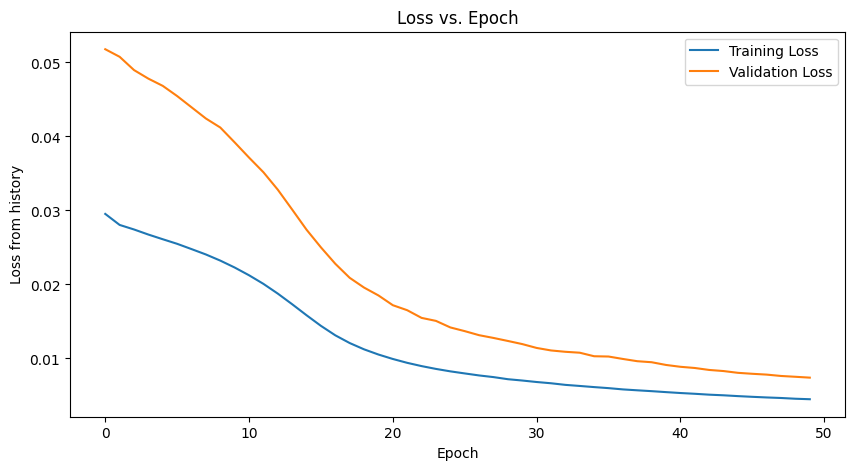

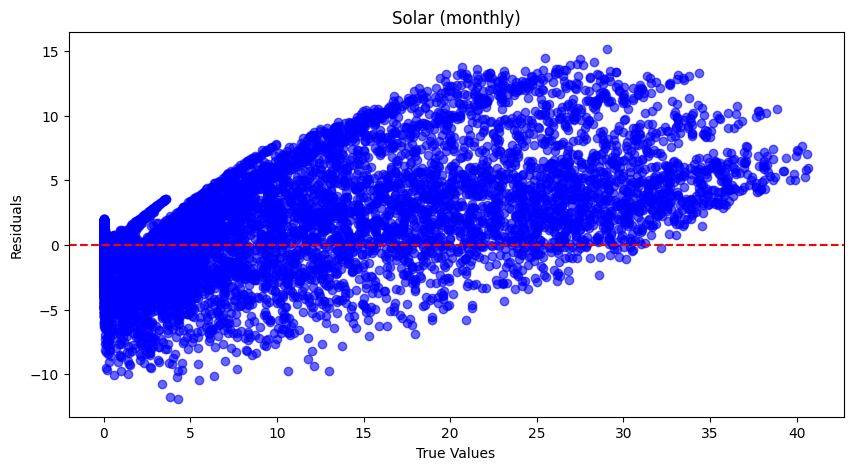

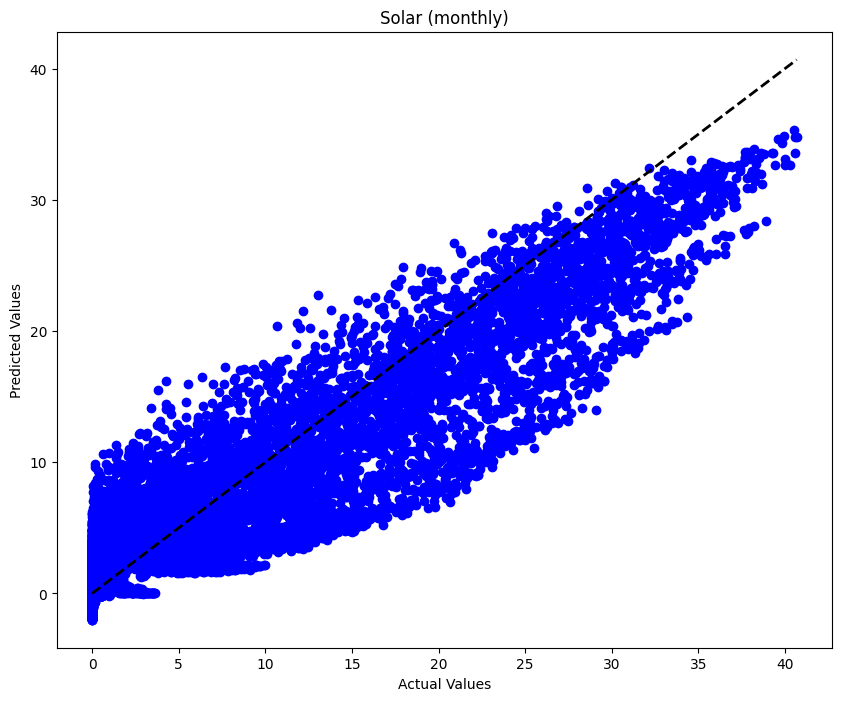

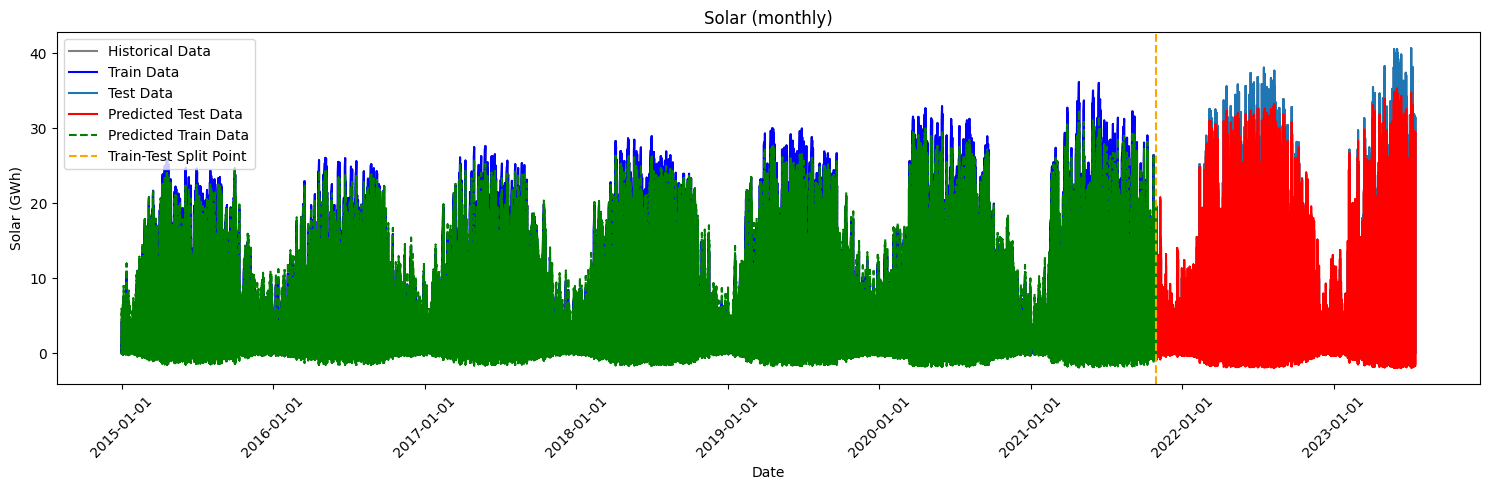

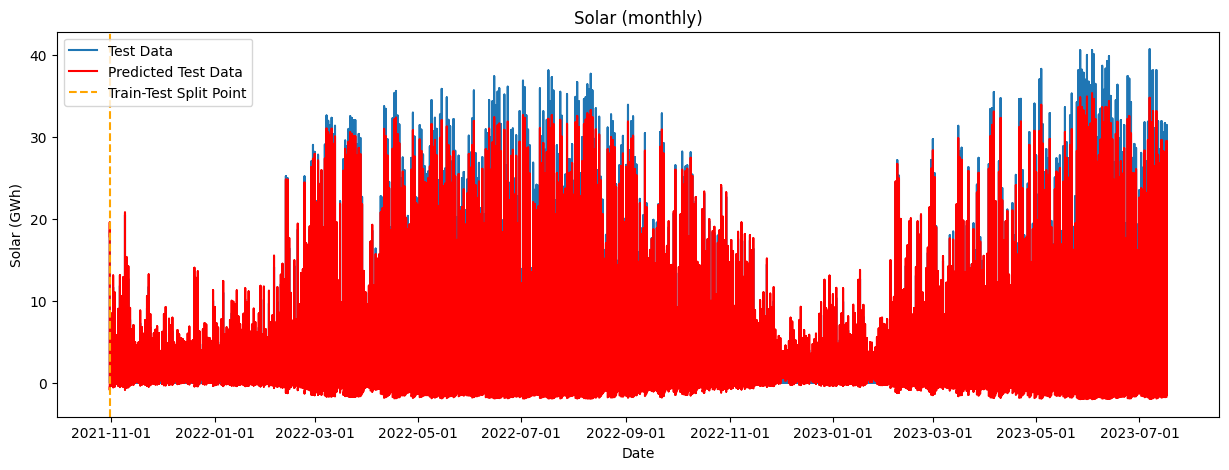

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_8 (LSTM)               (None, 12, 64)            16896     
                                                                 
 dropout_4 (Dropout)         (None, 12, 64)            0         
                                                                 
 lstm_9 (LSTM)               (None, 32)                12416     
                                                                 
 dense_4 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


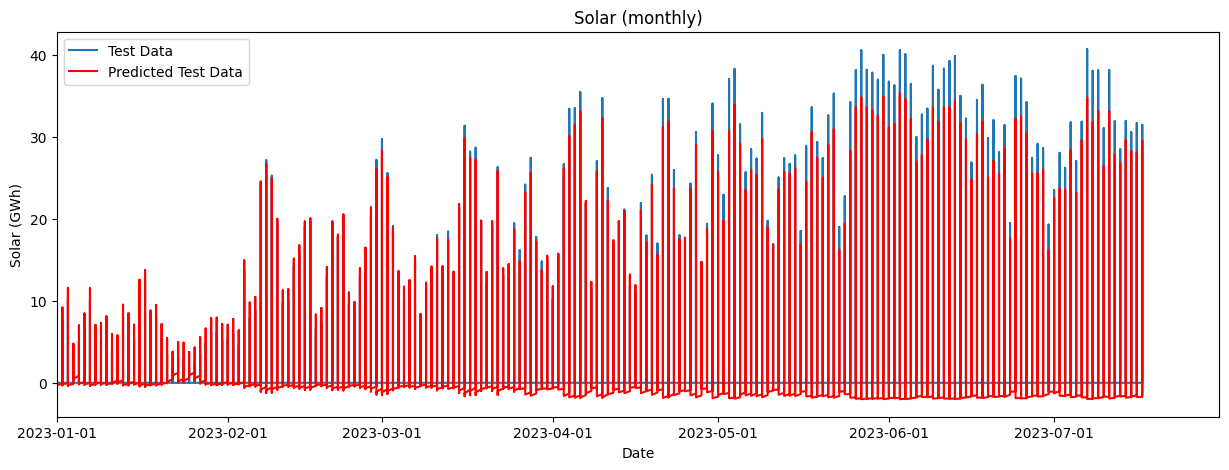

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 1)


In [67]:

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

    #optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.99999)
    optimizer = SGD(learning_rate=0.0001, momentum=0.9)
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(Dropout(0.2))  # Adding dropout regularization to the first LSTM layer
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer= optimizer)
    ##
    ##
    # Adding early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=10,
                        validation_data=(X_test_lstm, y_test_lstm),
                        callbacks=[early_stopping], verbose=2)

    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)
    return model
lookback=12
results = lstm_model('Solar_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  


# Rest of the code, including lookback and calling lstm_model, remains unchanged.


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_93947/3895635678.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/200
1198/1198 - 9s - loss: 0.0329 - val_loss: 0.0565 - 9s/epoch - 8ms/step
Epoch 2/200
1198/1198 - 8s - loss: 0.0300 - val_loss: 0.0550 - 8s/epoch - 7ms/step
Epoch 3/200
1198/1198 - 10s - loss: 0.0295 - val_loss: 0.0541 - 10s/epoch - 9ms/step
Epoch 4/200
1198/1198 - 8s - loss: 0.0292 - val_loss: 0.0536 - 8s/epoch - 6ms/step
Epoch 5/200
1198/1198 - 9s - loss: 0.0289 - val_loss: 0.0531 - 9s/epoch - 7ms/step
Epoch 6/200
1198/1198 - 9s - loss: 0.0287 - val_loss: 0.0527 - 9s/epoch - 7ms/step
Epoch 7/200
1198/1198 - 9s - loss: 0.0286 - val_loss: 0.0525 - 9s/epoch - 8ms/step
Epoch 8/200
1198/1198 - 8s - loss: 0.0284 - val_loss: 0.0523 - 8s/epoch - 7ms/step
Epoch 9/200
1198/1198 - 8s - loss: 0.0283 - val_loss: 0.0518 - 8s/epoch - 7ms/step
Epoch 10/200
1198/1198 - 8s - loss: 0.0281 - val_loss: 0.0515 - 8s/epoch - 7ms/step
Epoch 11/200
1198/1198 - 8s - loss: 0.0280 - val_loss: 0.0513 - 8s/epoch - 7ms/step
Epoch 12/200
1198/1198 - 8s - loss: 0.0278 - val_loss: 0.0511 - 8s/epoch - 7ms/step

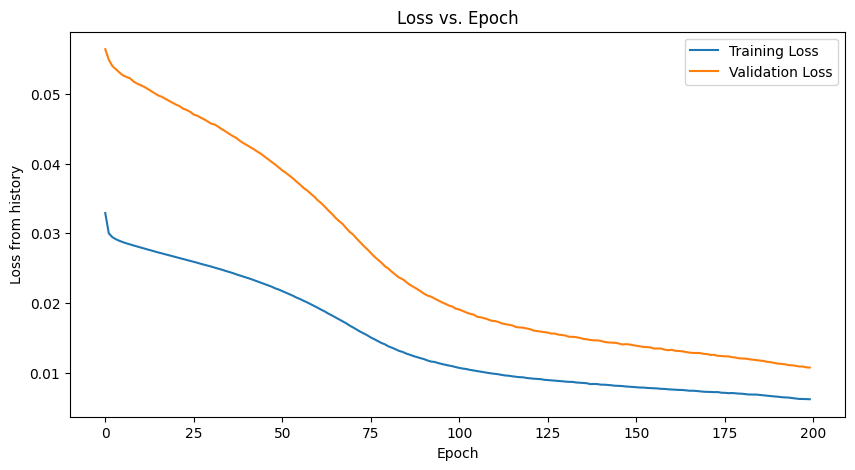

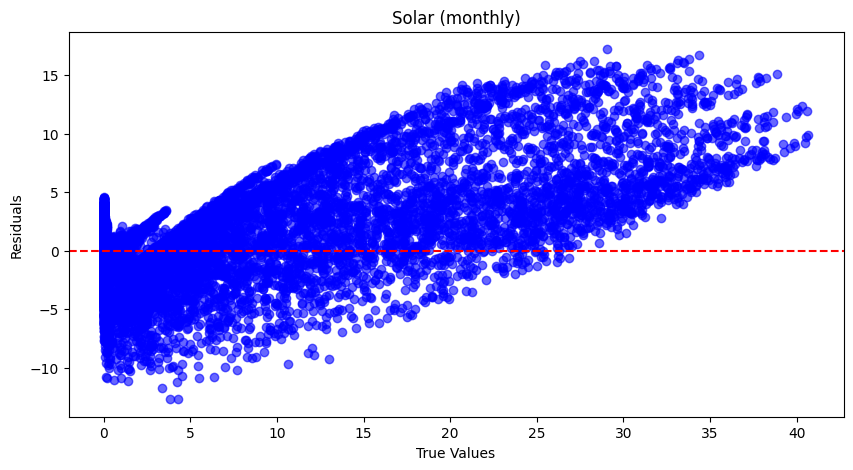

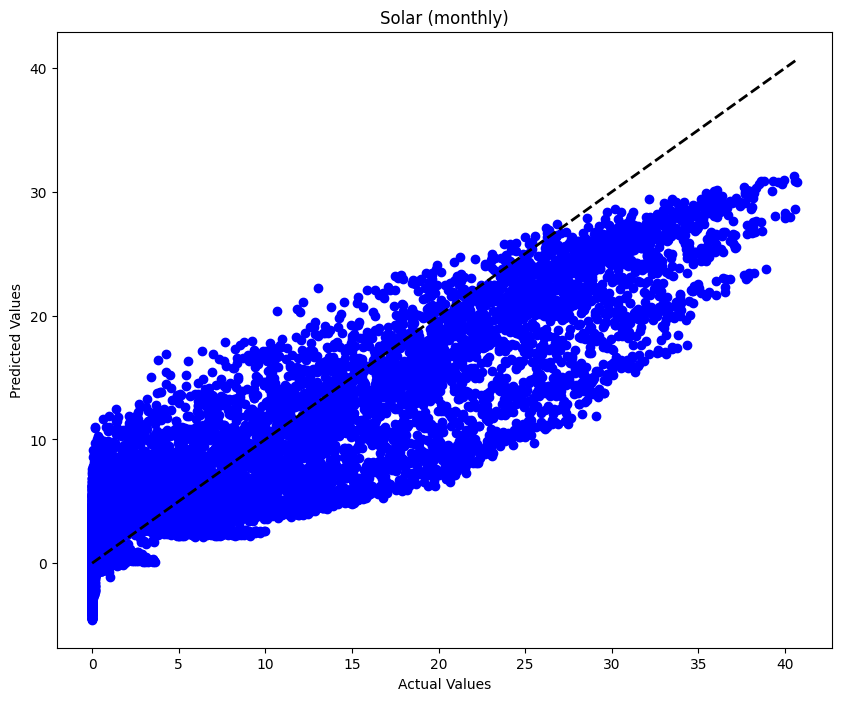

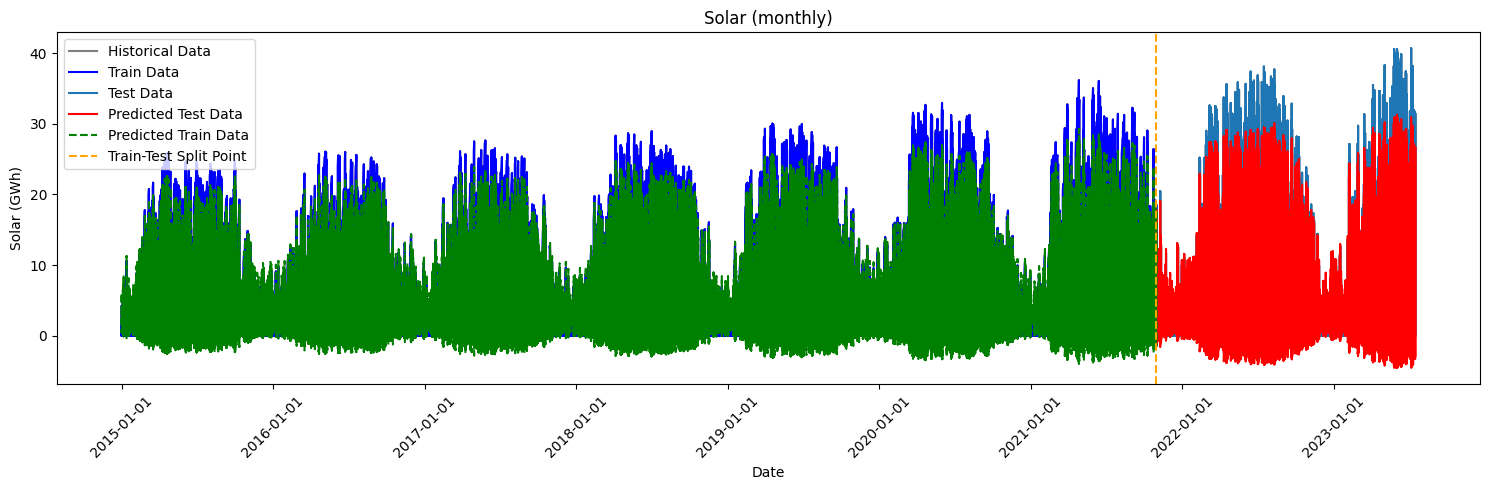

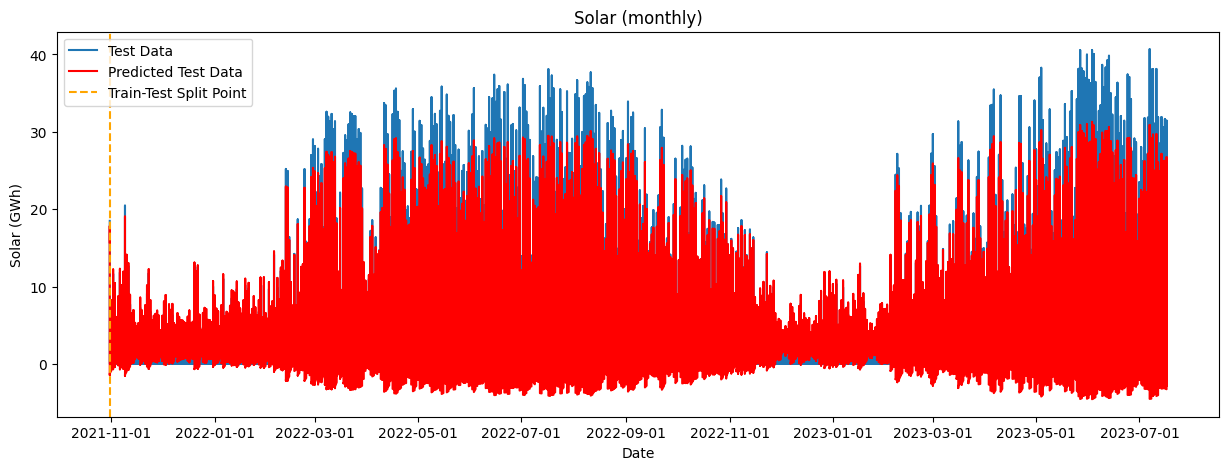

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_10 (LSTM)              (None, 12, 64)            16896     
                                                                 
 dropout_5 (Dropout)         (None, 12, 64)            0         
                                                                 
 lstm_11 (LSTM)              (None, 32)                12416     
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


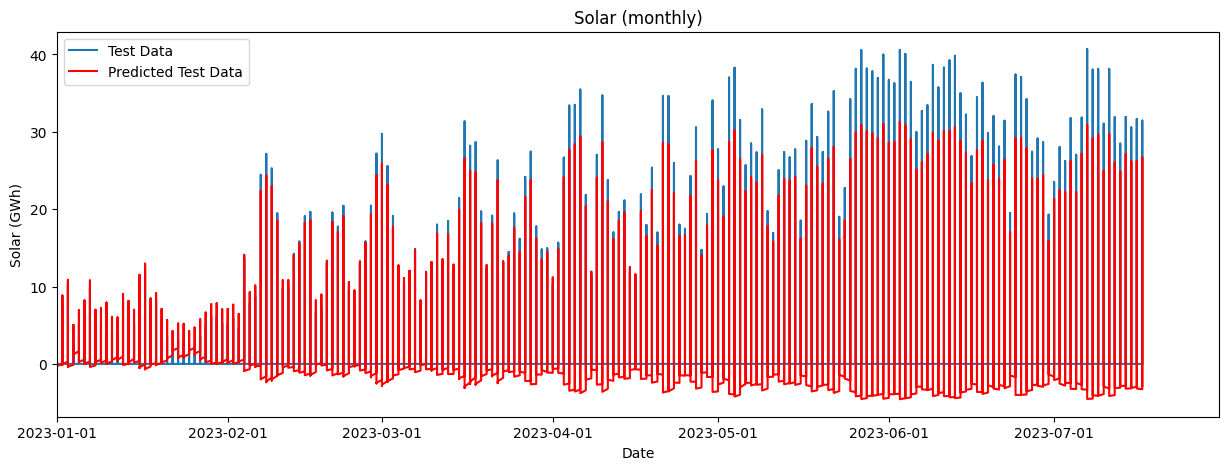

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 1)


In [68]:

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

    #optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.99999)
    optimizer = SGD(learning_rate=0.0001, momentum=0.9)
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(Dropout(0.2))  # Adding dropout regularization to the first LSTM layer
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer= optimizer)
    ##
    ##
    # Adding early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = model.fit(X_train_lstm, y_train_lstm, epochs=200, batch_size=50,
                        validation_data=(X_test_lstm, y_test_lstm),
                        callbacks=[early_stopping], verbose=2)

    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)
    return model
lookback=12
results = lstm_model('Solar_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  


# Rest of the code, including lookback and calling lstm_model, remains unchanged.


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_93947/1165879413.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/200
1198/1198 - 9s - loss: 0.0331 - val_loss: 0.0565 - 9s/epoch - 7ms/step
Epoch 2/200
1198/1198 - 7s - loss: 0.0303 - val_loss: 0.0555 - 7s/epoch - 6ms/step
Epoch 3/200
1198/1198 - 7s - loss: 0.0301 - val_loss: 0.0553 - 7s/epoch - 6ms/step
Epoch 4/200
1198/1198 - 8s - loss: 0.0300 - val_loss: 0.0550 - 8s/epoch - 6ms/step
Epoch 5/200
1198/1198 - 8s - loss: 0.0299 - val_loss: 0.0548 - 8s/epoch - 7ms/step
Epoch 6/200
1198/1198 - 7s - loss: 0.0298 - val_loss: 0.0546 - 7s/epoch - 6ms/step
Epoch 7/200
1198/1198 - 7s - loss: 0.0297 - val_loss: 0.0545 - 7s/epoch - 6ms/step
Epoch 8/200
1198/1198 - 7s - loss: 0.0296 - val_loss: 0.0543 - 7s/epoch - 6ms/step
Epoch 9/200
1198/1198 - 7s - loss: 0.0295 - val_loss: 0.0541 - 7s/epoch - 6ms/step
Epoch 10/200
1198/1198 - 7s - loss: 0.0295 - val_loss: 0.0541 - 7s/epoch - 6ms/step
Epoch 11/200
1198/1198 - 7s - loss: 0.0294 - val_loss: 0.0539 - 7s/epoch - 6ms/step
Epoch 12/200
1198/1198 - 7s - loss: 0.0293 - val_loss: 0.0538 - 7s/epoch - 6ms/step
E

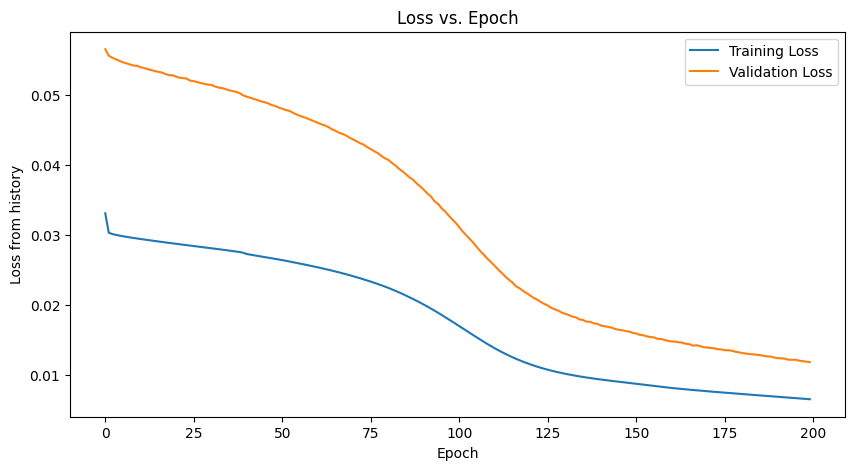

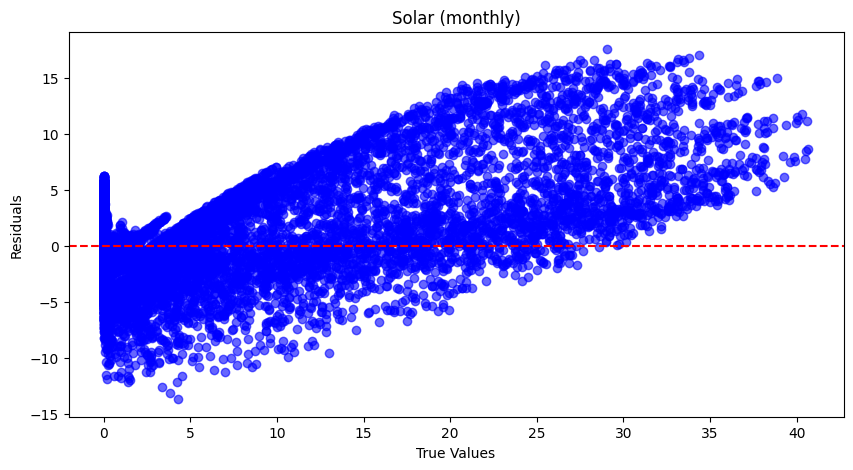

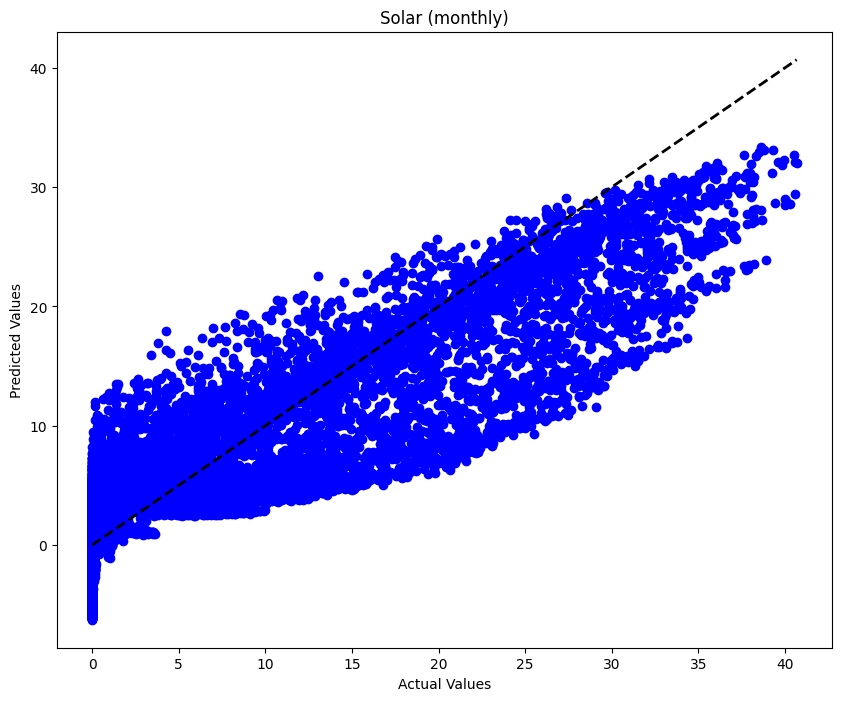

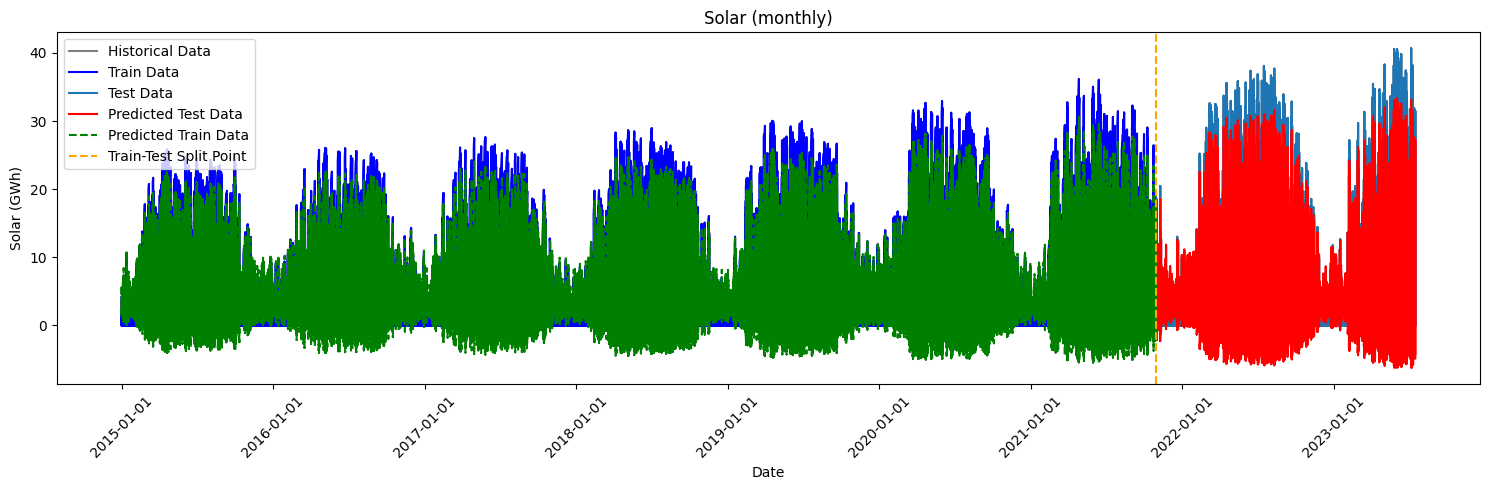

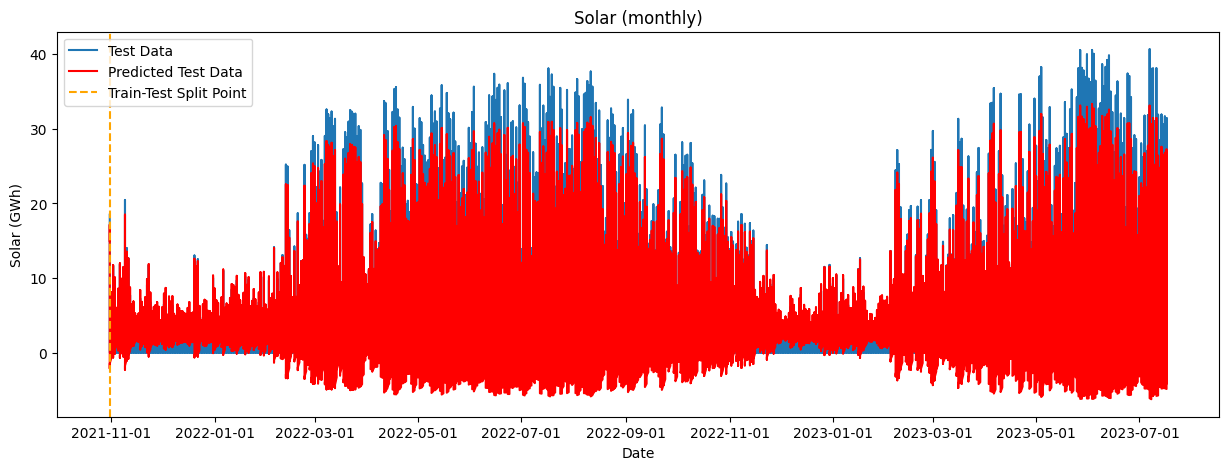

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_12 (LSTM)              (None, 12, 64)            16896     
                                                                 
 dropout_6 (Dropout)         (None, 12, 64)            0         
                                                                 
 lstm_13 (LSTM)              (None, 32)                12416     
                                                                 
 dense_6 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


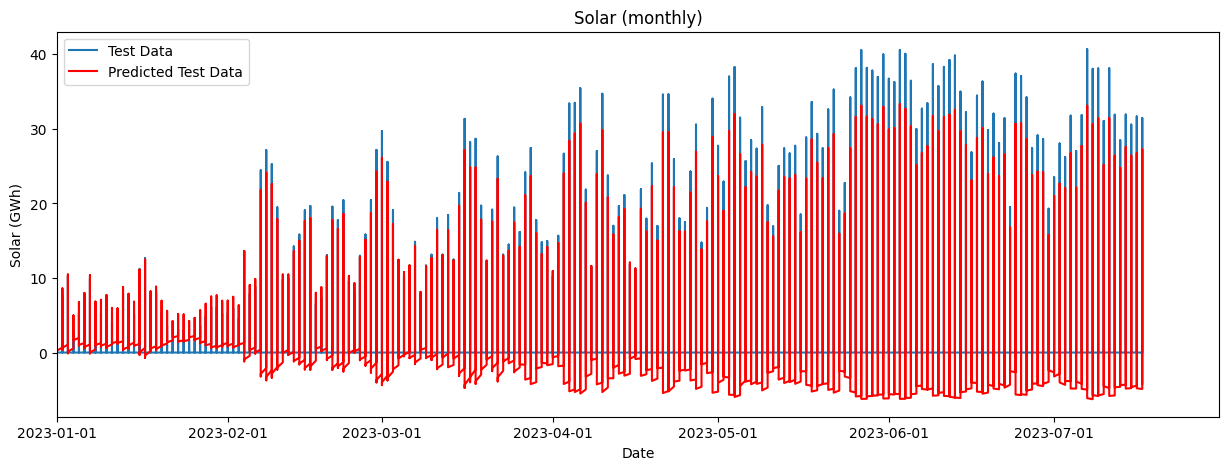

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 1)


In [69]:

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

    #optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.99999)
    optimizer = SGD(learning_rate=0.0001, momentum=0.9)
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(Dropout(0.0))  # Adding dropout regularization to the first LSTM layer
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer= optimizer)
    ##
    ##
    # Adding early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = model.fit(X_train_lstm, y_train_lstm, epochs=200, batch_size=50,
                        validation_data=(X_test_lstm, y_test_lstm),
                        callbacks=[early_stopping], verbose=2)

    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)
    return model
lookback=12
results = lstm_model('Solar_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  


# Rest of the code, including lookback and calling lstm_model, remains unchanged.


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_93947/3923200361.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/400
1198/1198 [==============================] - 8s 6ms/step - loss: 0.0321 - val_loss: 0.0552
Epoch 2/400
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0297 - val_loss: 0.0543
Epoch 3/400
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0294 - val_loss: 0.0539
Epoch 4/400
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0292 - val_loss: 0.0534
Epoch 5/400
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0290 - val_loss: 0.0531
Epoch 6/400
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0289 - val_loss: 0.0528
Epoch 7/400
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0287 - val_loss: 0.0524
Epoch 8/400
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0286 - val_loss: 0.0522
Epoch 9/400
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0284 - val_loss: 0.0520
Epoch 10/400
1198/1198 [==============================] - 7s 6ms/step - l

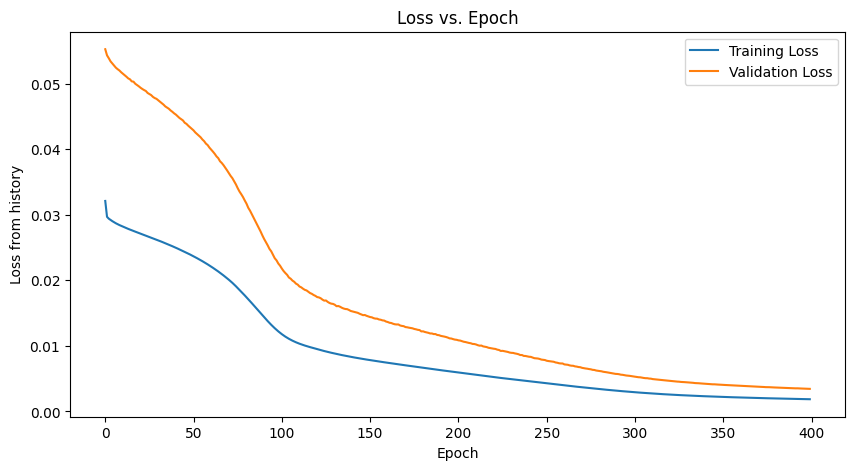

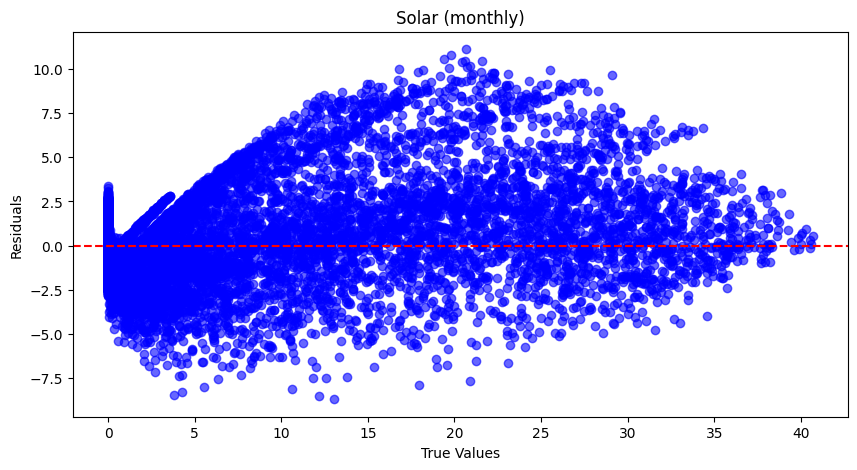

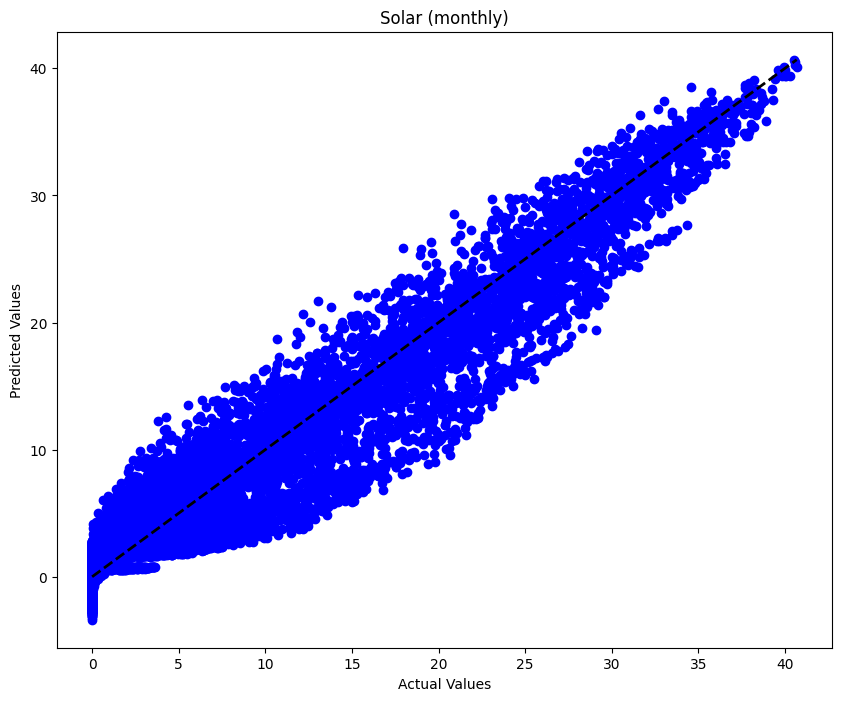

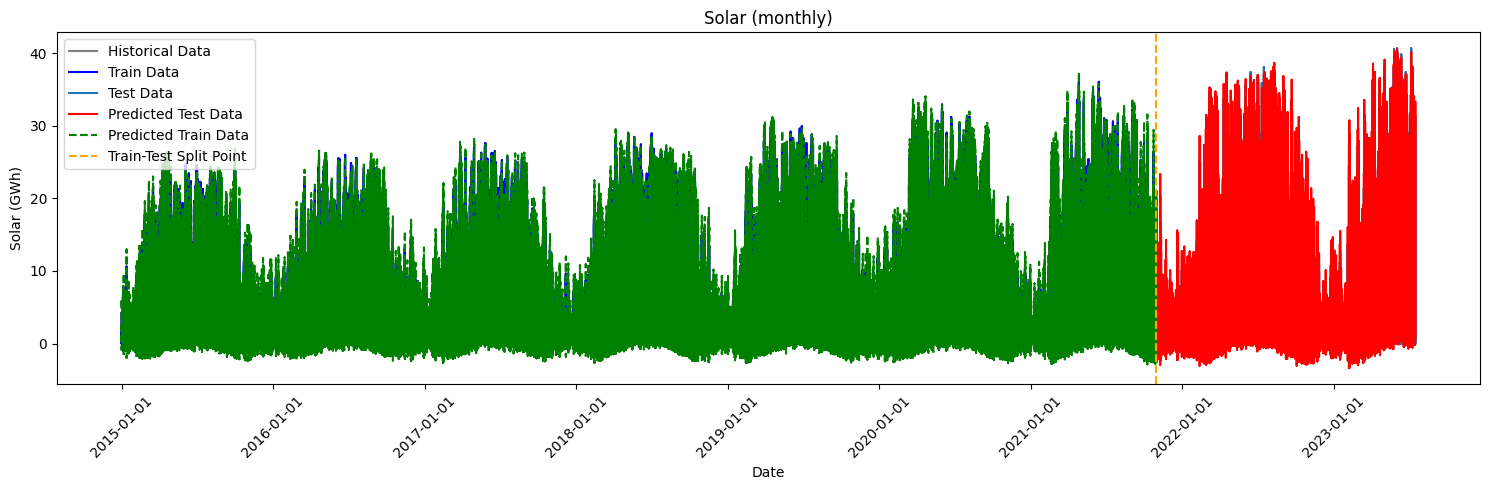

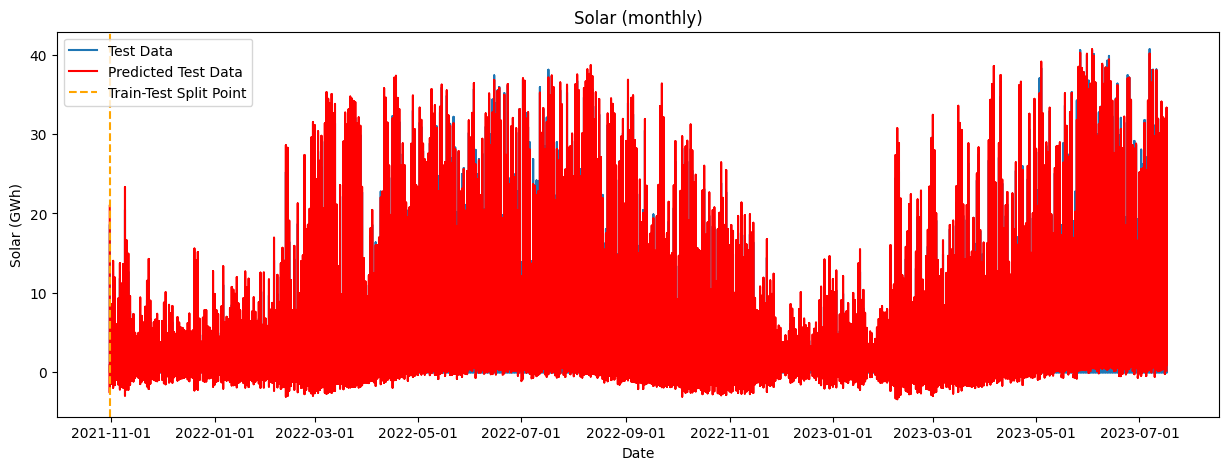

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_14 (LSTM)              (None, 12, 64)            16896     
                                                                 
 dropout_7 (Dropout)         (None, 12, 64)            0         
                                                                 
 lstm_15 (LSTM)              (None, 32)                12416     
                                                                 
 dense_7 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


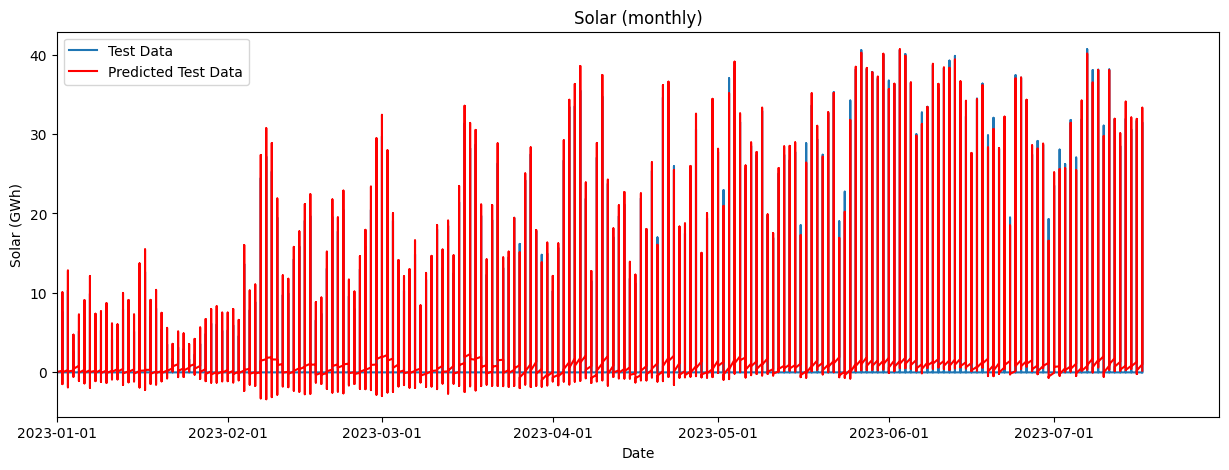

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 1)


In [70]:

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

    #optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.99999)
    optimizer = SGD(learning_rate=0.0001, momentum=0.9)
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(Dropout(0.0))  # Adding dropout regularization to the first LSTM layer
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer= optimizer)
    ##
    ##
    # Adding early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = model.fit(X_train_lstm, y_train_lstm, epochs=400, batch_size=50,
                        validation_data=(X_test_lstm, y_test_lstm),
                        callbacks=[early_stopping], verbose=1)

    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)
    return model
lookback=12
results = lstm_model('Solar_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  


# Rest of the code, including lookback and calling lstm_model, remains unchanged.


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_93947/241587997.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/800
1198/1198 [==============================] - 19s 15ms/step - loss: 0.0320 - val_loss: 0.0556
Epoch 2/800
1198/1198 [==============================] - 15s 12ms/step - loss: 0.0301 - val_loss: 0.0551
Epoch 3/800
1198/1198 [==============================] - 14s 12ms/step - loss: 0.0299 - val_loss: 0.0546
Epoch 4/800
1198/1198 [==============================] - 14s 12ms/step - loss: 0.0297 - val_loss: 0.0543
Epoch 5/800
1198/1198 [==============================] - 13s 11ms/step - loss: 0.0295 - val_loss: 0.0541
Epoch 6/800
1198/1198 [==============================] - 13s 11ms/step - loss: 0.0293 - val_loss: 0.0539
Epoch 7/800
1198/1198 [==============================] - 13s 11ms/step - loss: 0.0292 - val_loss: 0.0536
Epoch 8/800
1198/1198 [==============================] - 13s 11ms/step - loss: 0.0290 - val_loss: 0.0532
Epoch 9/800
1198/1198 [==============================] - 13s 10ms/step - loss: 0.0289 - val_loss: 0.0531
Epoch 10/800
1198/1198 [==============================]

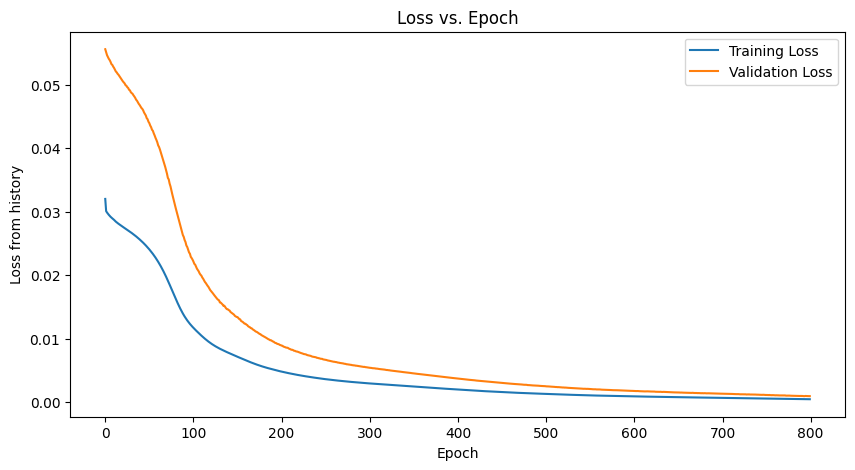

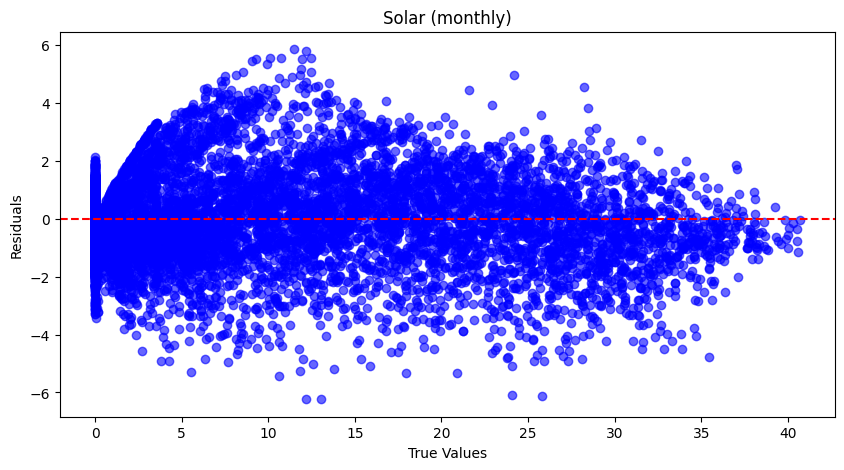

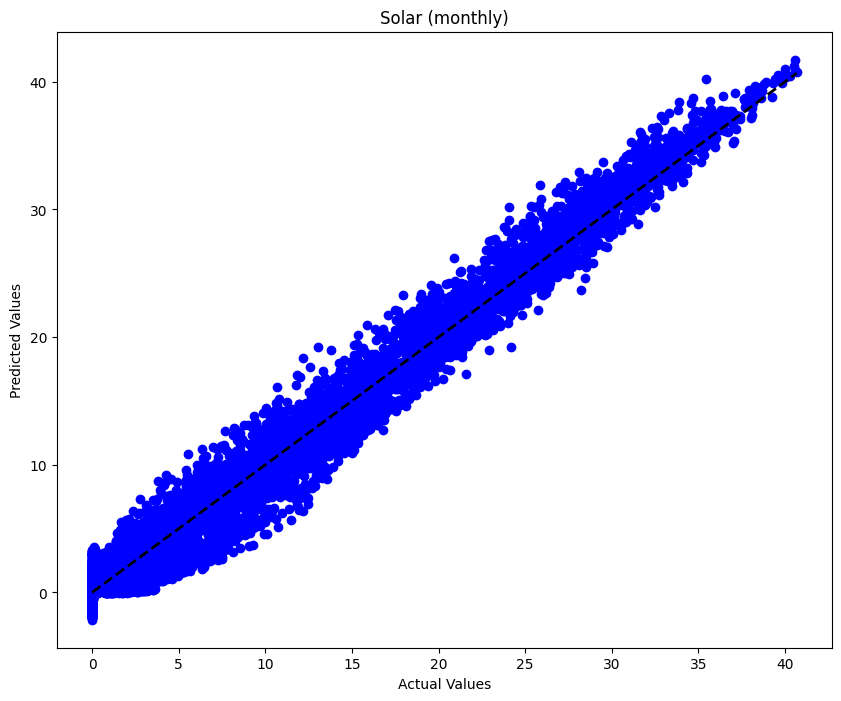

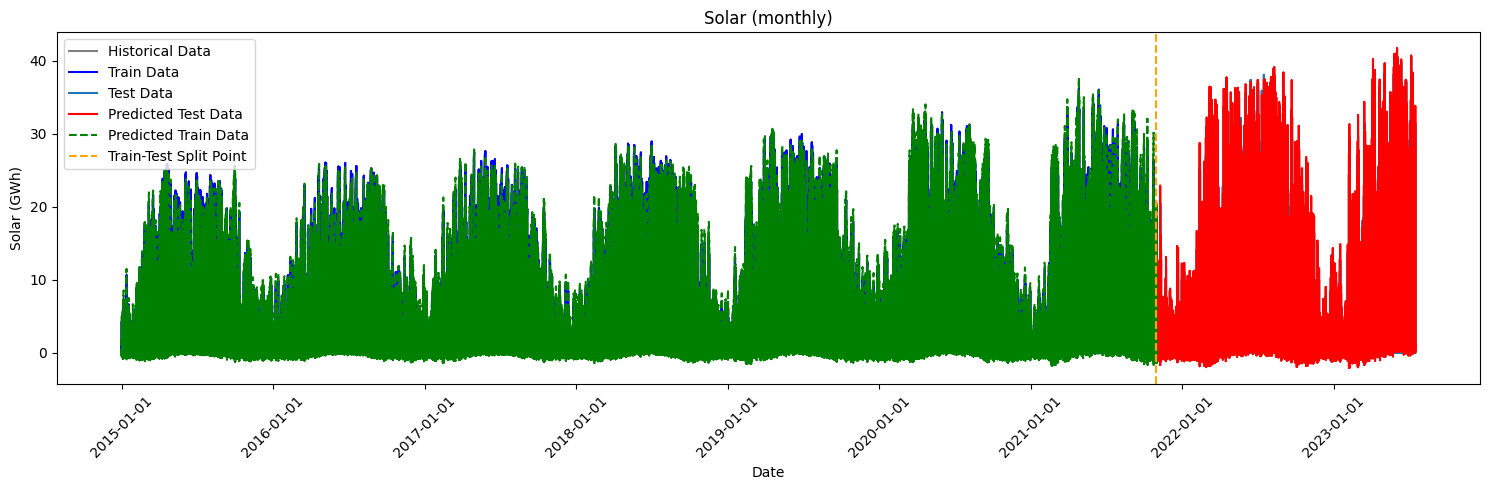

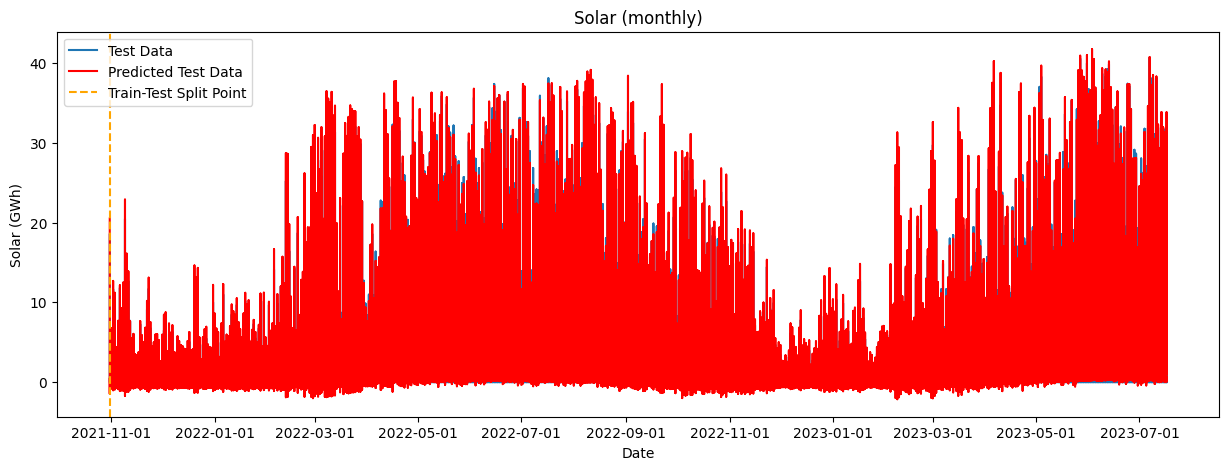

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_16 (LSTM)              (None, 12, 64)            16896     
                                                                 
 dropout_8 (Dropout)         (None, 12, 64)            0         
                                                                 
 lstm_17 (LSTM)              (None, 32)                12416     
                                                                 
 dense_8 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


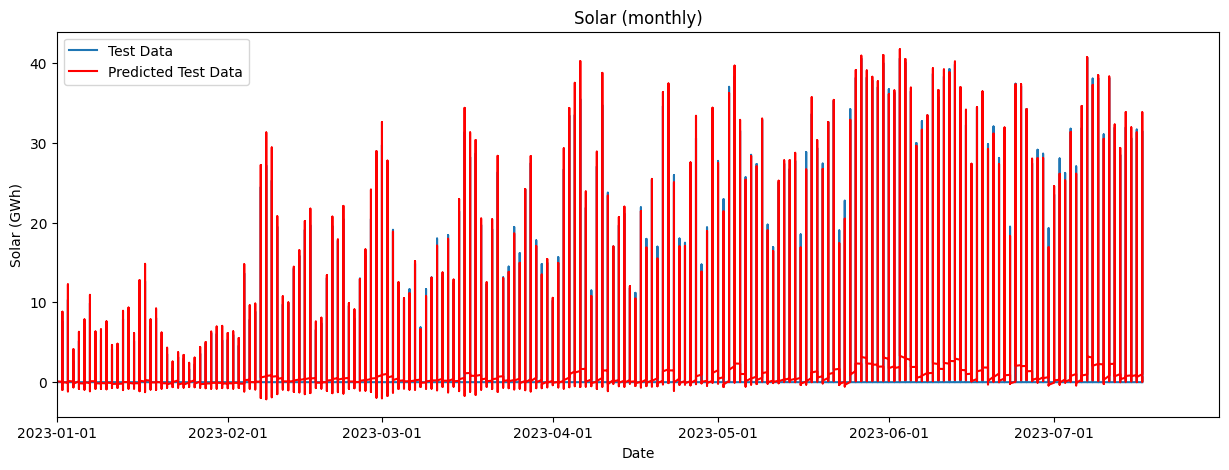

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 1)


In [71]:

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

    #optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.99999)
    optimizer = SGD(learning_rate=0.0001, momentum=0.9)
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(Dropout(0.0))  # Adding dropout regularization to the first LSTM layer
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer= optimizer)
    ##
    ##
    # Adding early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = model.fit(X_train_lstm, y_train_lstm, epochs=800, batch_size=50,
                        validation_data=(X_test_lstm, y_test_lstm),
                        callbacks=[early_stopping], verbose=1)

    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)
    return model
lookback=12
results = lstm_model('Solar_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  


# Rest of the code, including lookback and calling lstm_model, remains unchanged.


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_93947/1675700981.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/800
1198/1198 [==============================] - 11s 8ms/step - loss: 0.0313 - val_loss: 0.0540
Epoch 2/800
1198/1198 [==============================] - 10s 8ms/step - loss: 0.0292 - val_loss: 0.0530
Epoch 3/800
1198/1198 [==============================] - 9s 7ms/step - loss: 0.0289 - val_loss: 0.0525
Epoch 4/800
1198/1198 [==============================] - 9s 7ms/step - loss: 0.0287 - val_loss: 0.0522
Epoch 5/800
1198/1198 [==============================] - 9s 7ms/step - loss: 0.0285 - val_loss: 0.0518
Epoch 6/800
1198/1198 [==============================] - 9s 7ms/step - loss: 0.0284 - val_loss: 0.0516
Epoch 7/800
1198/1198 [==============================] - 9s 7ms/step - loss: 0.0282 - val_loss: 0.0514
Epoch 8/800
1198/1198 [==============================] - 9s 7ms/step - loss: 0.0281 - val_loss: 0.0510
Epoch 9/800
1198/1198 [==============================] - 9s 7ms/step - loss: 0.0280 - val_loss: 0.0509
Epoch 10/800
1198/1198 [==============================] - 9s 7ms/step -

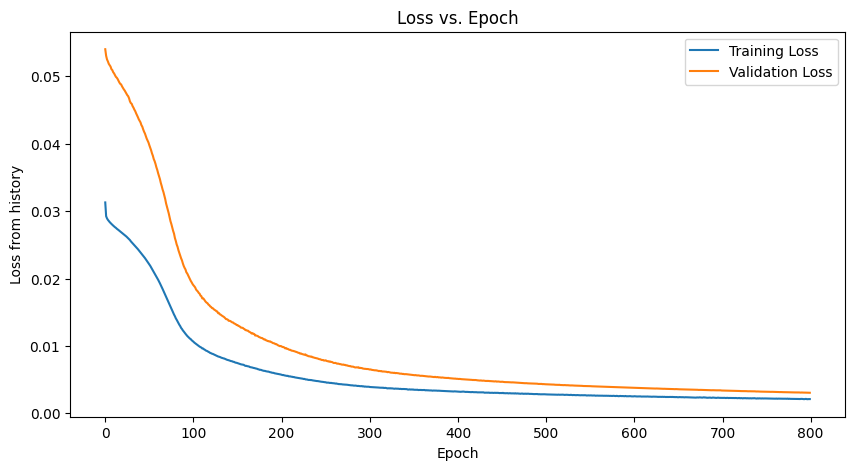

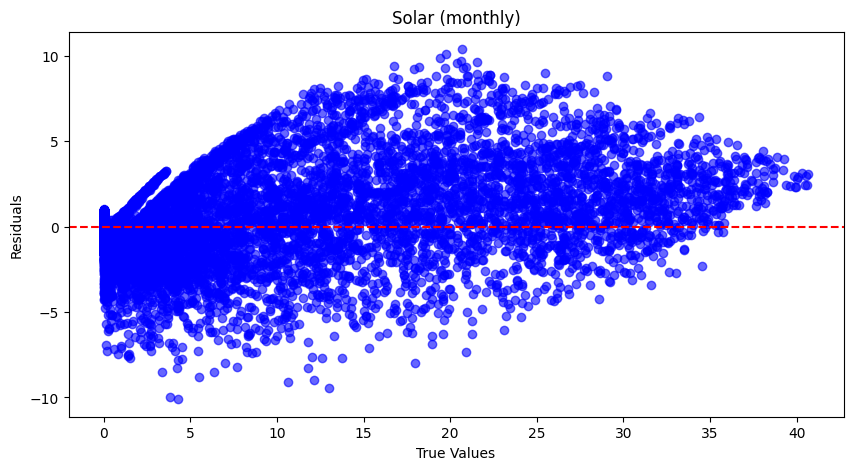

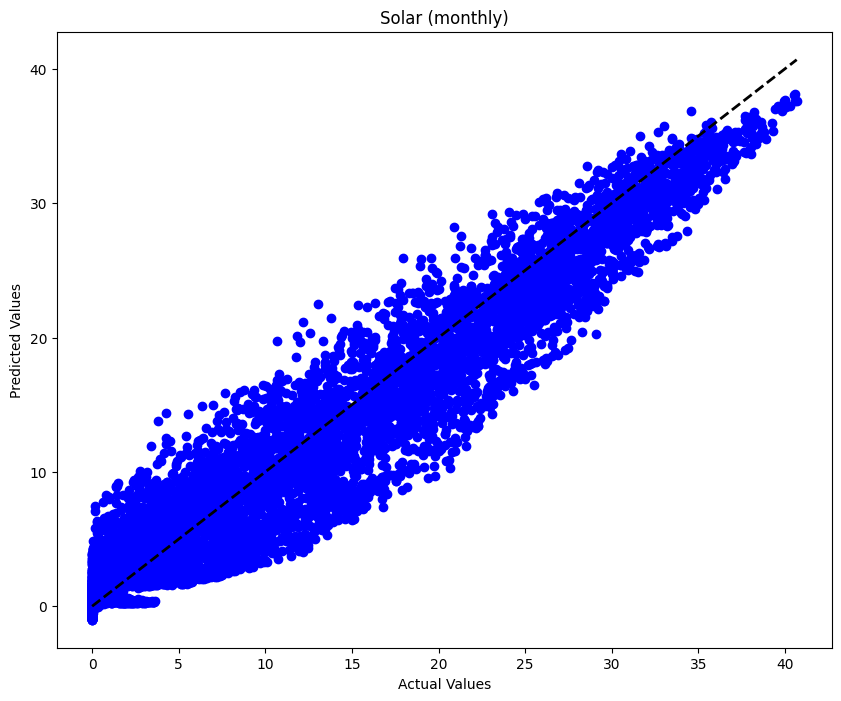

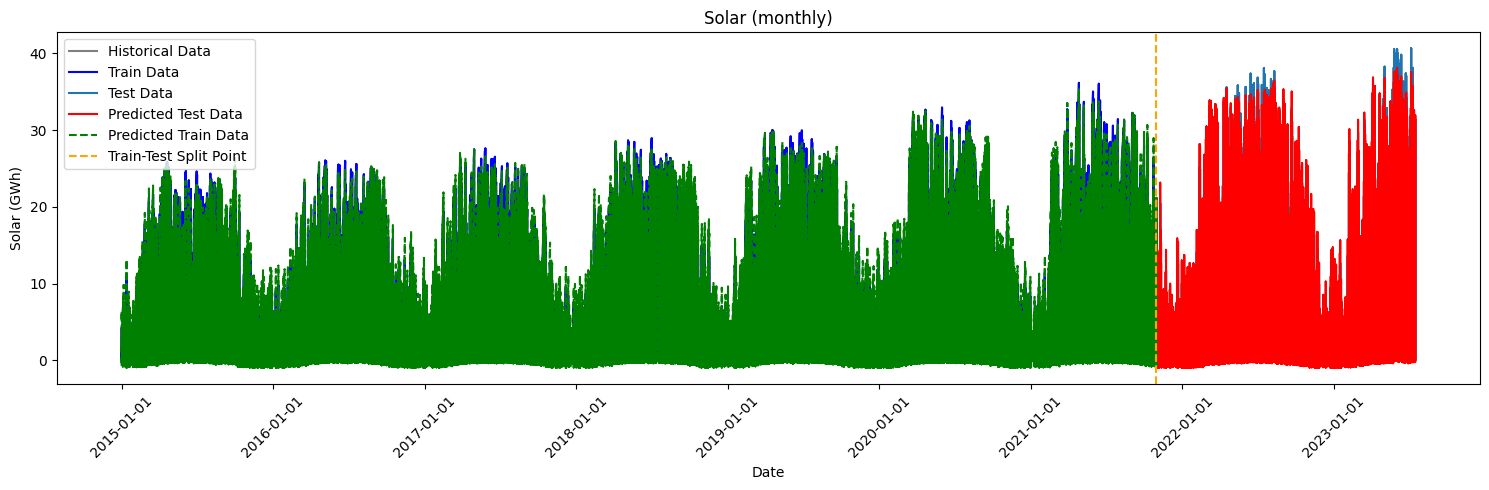

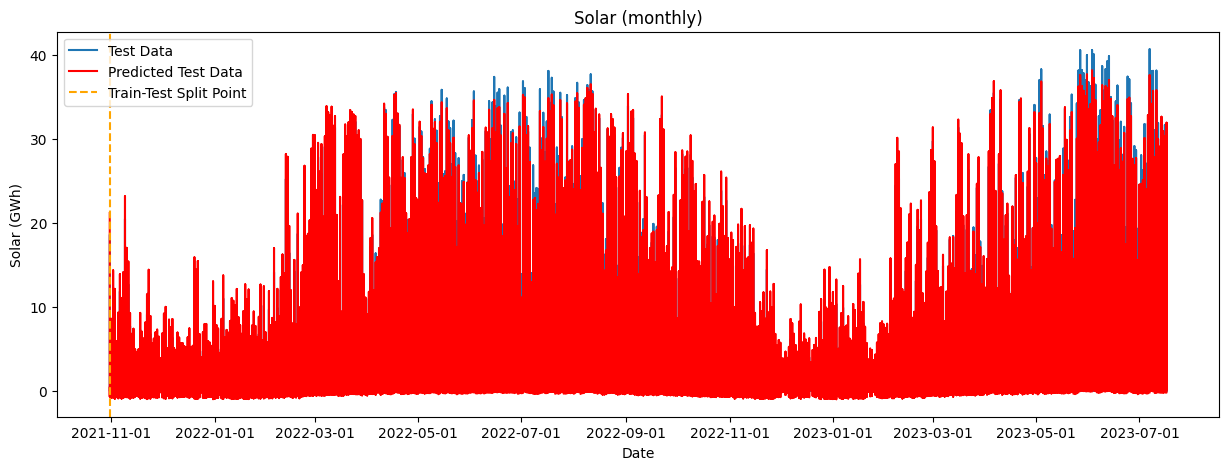

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_18 (LSTM)              (None, 12, 64)            16896     
                                                                 
 dropout_9 (Dropout)         (None, 12, 64)            0         
                                                                 
 lstm_19 (LSTM)              (None, 32)                12416     
                                                                 
 dense_9 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


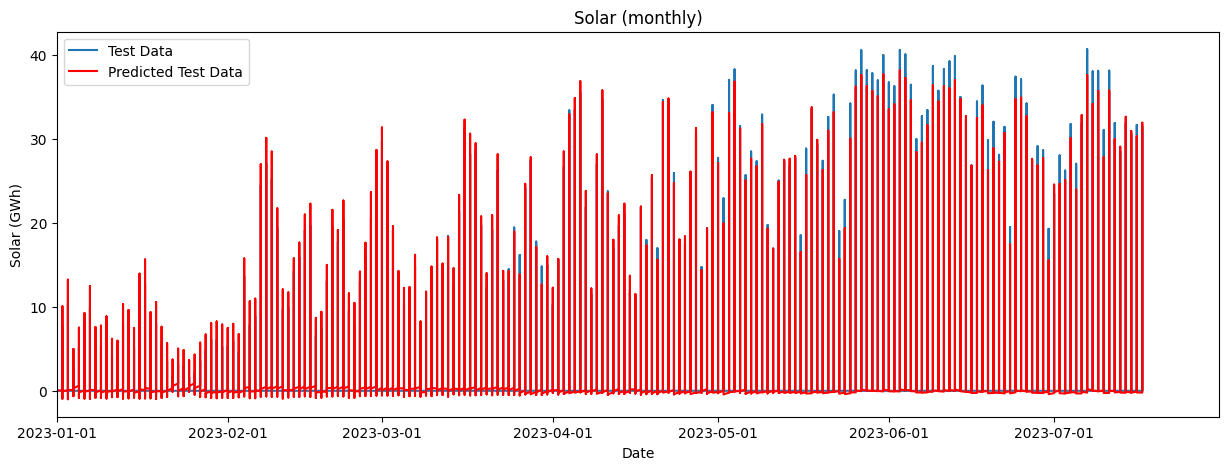

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 1)


In [72]:

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

    #optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.99999)
    optimizer = SGD(learning_rate=0.0001, momentum=0.9)
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(Dropout(0.2))  # Adding dropout regularization to the first LSTM layer
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer= optimizer)
    ##
    ##
    # Adding early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = model.fit(X_train_lstm, y_train_lstm, epochs=800, batch_size=50,
                        validation_data=(X_test_lstm, y_test_lstm),
                        callbacks=[early_stopping], verbose=1)

    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())‚
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)
    return model
lookback=12
results = lstm_model('Solar_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  


# Rest of the code, including lookback and calling lstm_model, remains unchanged.


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_1688/3099328933.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/800
1198/1198 [==============================] - 8s 6ms/step - loss: 0.0313 - val_loss: 0.0538
Epoch 2/800
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0292 - val_loss: 0.0529
Epoch 3/800
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0288 - val_loss: 0.0525
Epoch 4/800
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0284 - val_loss: 0.0517
Epoch 5/800
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0281 - val_loss: 0.0512
Epoch 6/800
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0279 - val_loss: 0.0508
Epoch 7/800
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0277 - val_loss: 0.0504
Epoch 8/800
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0275 - val_loss: 0.0502
Epoch 9/800
1198/1198 [==============================] - 7s 6ms/step - loss: 0.0274 - val_loss: 0.0499
Epoch 10/800
1198/1198 [==============================] - 7s 6ms/step - l

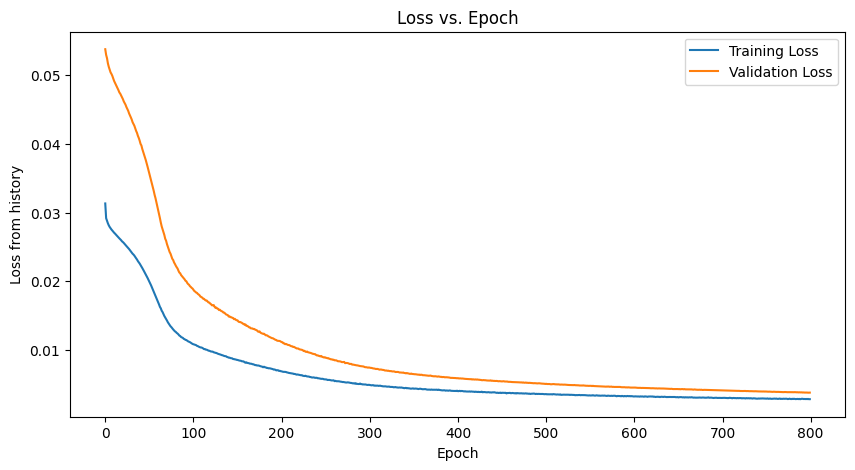

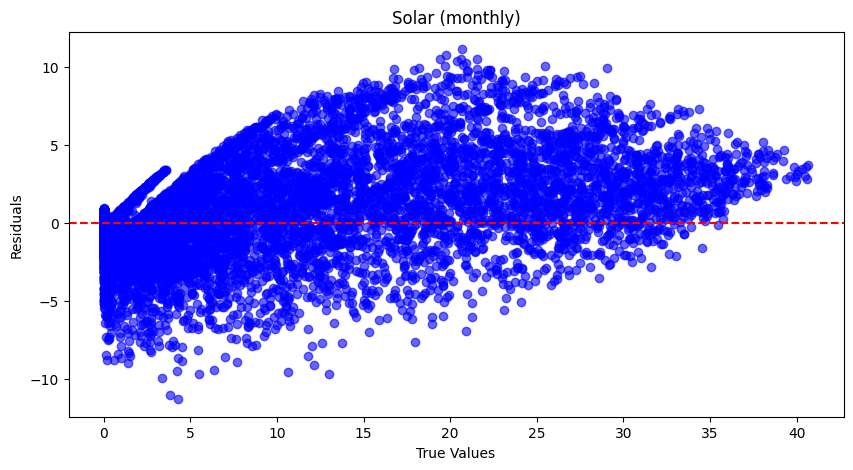

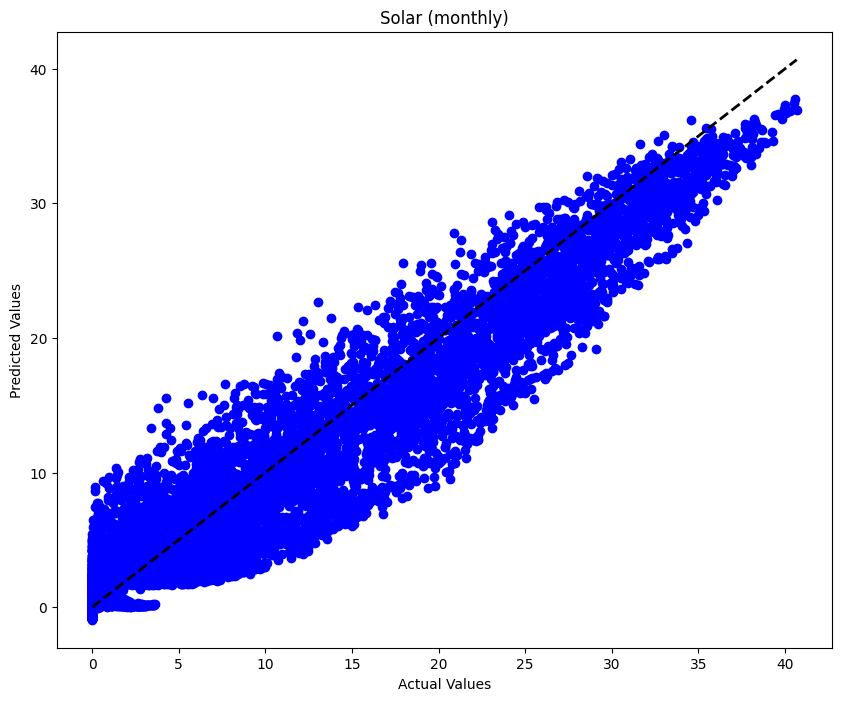

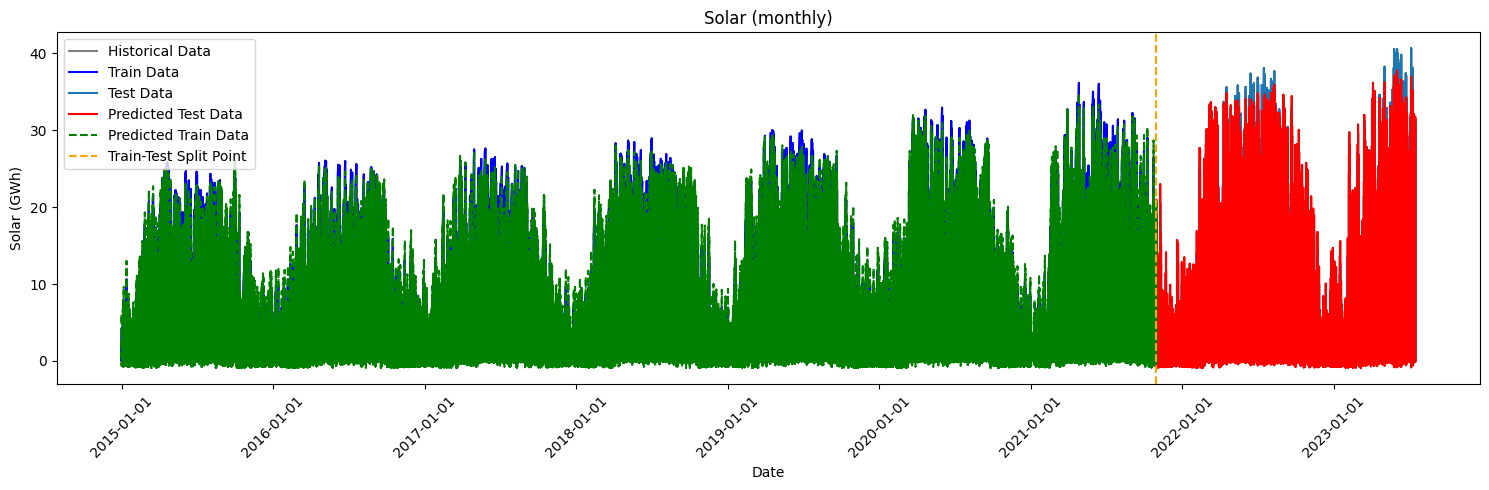

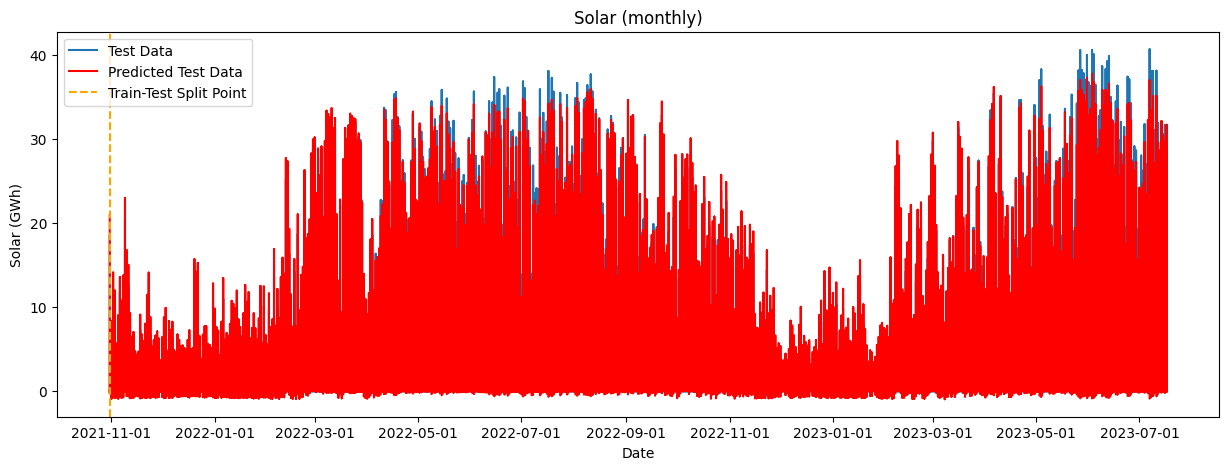

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 12, 64)            16896     
                                                                 
 dropout (Dropout)           (None, 12, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


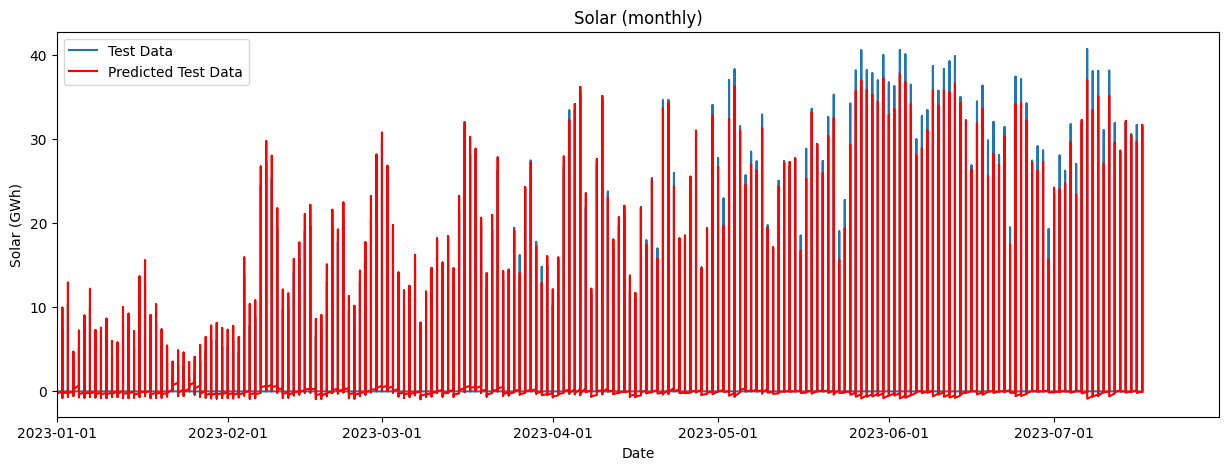

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 1)


In [61]:

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

    #optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.99999)
    optimizer = SGD(learning_rate=0.0001, momentum=0.9)
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(Dropout(0.4))  # Adding dropout regularization to the first LSTM layer
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer= optimizer)
    ##
    ##
    # Adding early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = model.fit(X_train_lstm, y_train_lstm, epochs=800, batch_size=50,
                        validation_data=(X_test_lstm, y_test_lstm),
                        callbacks=[early_stopping], verbose=1)

    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)
    return model
lookback=12
results = lstm_model('Solar_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  


# Rest of the code, including lookback and calling lstm_model, remains unchanged.


#### Momentum and SGD with dropout and regurlization [L2 (Ridge) regression]

In [ ]:

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

    #optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.99999)
    optimizer = SGD(learning_rate=0.0001, momentum=0.9)
   


    # Define the regularization strength (you can adjust this value as needed)
    # Create the model
    ##
    ##
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=32, activation='relu', kernel_regularizer=l2(reg_strength= 0.01)))  # Adding L2 regularization to the second LSTM layer
    model.add(Dense(1, kernel_regularizer=l2(reg_strength = 0.01)))  # Adding L2 regularization to the Dense layer
    model.compile(loss='mse', optimizer=optimizer)
    ##
    ##
    # Adding early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = model.fit(X_train_lstm, y_train_lstm, epochs=800, batch_size=50,
                        validation_data=(X_test_lstm, y_test_lstm),
                        callbacks=[early_stopping], verbose=1)

    print(model.summary())

    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)


    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')

    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print(model.summary()) 

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    #plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)
    return model
lookback=12
results = lstm_model('Solar_gwh', data_df, lookback) 
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  


# Rest of the code, including lookback and calling lstm_model, remains unchanged.


#### Momentum and SGD with dropout and regurlization [L1 (Lasso)  regression]

In [ ]:
from keras.regularizers import l2

# Define the regularization strength (you can adjust this value as needed)
reg_strength = 0.01

# Create the model
model = Sequential()
model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(units=32, activation='relu', kernel_regularizer=l2(reg_strength)))  # Adding L2 regularization to the second LSTM layer
model.add(Dense(1, kernel_regularizer=l2(reg_strength)))  # Adding L2 regularization to the Dense layer
model.compile(loss='mse', optimizer=optimizer)



In [ ]:
from keras.regularizers import l1

# Define the regularization strength (you can adjust this value as needed)
reg_strength = 0.01

# Create the model
model = Sequential()
model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(units=32, activation='relu', kernel_regularizer=l1(reg_strength)))  # Adding L1 regularization to the second LSTM layer
model.add(Dense(1, kernel_regularizer=l1(reg_strength)))  # Adding L1 regularization to the Dense layer
model.compile(loss='mse', optimizer=optimizer)


In [ ]:
from tensorflow.keras.regularizers import l1, l2

# Define the regularization strength (you can adjust this value as needed)
reg_strength = 0.01

# Create the model
model = Sequential()
model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(units=32, activation='relu', kernel_regularizer=l1(reg_strength)))  # Adding L1 regularization to the second LSTM layer
model.add(Dense(1, kernel_regularizer=l1(reg_strength)))  # Adding L1 regularization to the Dense layer
model.compile(loss='mse', optimizer=optimizer)


#### Multivariate LSTM

#### Working code

In [1043]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])
        y.append(data[i+lookback, -1])
    return np.array(X), np.array(y)

def lstm_mlvrt(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        data_df['Date'] = pd.to_datetime(data_df['Date'])
        data_df.set_index('Date', inplace=True)
        dfs_resampled = data_df[features + [target]].resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df[features + [target]]
    
    if rolling_mean:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=ma_window, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled.values)
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_pred_train_lstm)))
    y_pred_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_pred_test_lstm)))
    y_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_train_lstm.reshape(-1, 1))))
    y_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_test_lstm.reshape(-1, 1))))
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1]))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1]))
    train_mse = mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mse = mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_mae = mean_absolute_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mae = mean_absolute_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_r2 = r2_score(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_r2 = r2_score(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    
    # Calculate residuals
    residuals = y_test_lstm[:, -1] - y_pred_test_lstm[:, -1]

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    
    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm[:, -1], residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm[:, -1], y_pred_test_lstm[:, -1], label='', color='blue')
    plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[-len(y_test_lstm):]  # Ensure test_index and y_test_lstm have the same length
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm[:, -1], label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm[:, -1], label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm[:, -1], label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm[:, -1], label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'X_test_lstm': X_test_lstm
    }


In [1036]:
data = data_df.copy()

Epoch 1/30
11976/11976 [==============================] - 101s 8ms/step - loss: 0.0057 - val_loss: 0.0095
Epoch 2/30
11976/11976 [==============================] - 95s 8ms/step - loss: 0.0045 - val_loss: 0.0071
Epoch 3/30
11976/11976 [==============================] - 101s 8ms/step - loss: 0.0043 - val_loss: 0.0053
Epoch 4/30
11976/11976 [==============================] - 101s 8ms/step - loss: 0.0041 - val_loss: 0.0058
Epoch 5/30
11976/11976 [==============================] - 100s 8ms/step - loss: 0.0040 - val_loss: 0.0067
Epoch 6/30
11976/11976 [==============================] - 94s 8ms/step - loss: 0.0039 - val_loss: 0.0063
Epoch 7/30
11976/11976 [==============================] - 102s 9ms/step - loss: 0.0039 - val_loss: 0.0066
Epoch 8/30
11976/11976 [==============================] - 101s 8ms/step - loss: 0.0038 - val_loss: 0.0068
Epoch 9/30
11976/11976 [==============================] - 96s 8ms/step - loss: 0.0037 - val_loss: 0.0073
Epoch 10/30
11976/11976 [========================

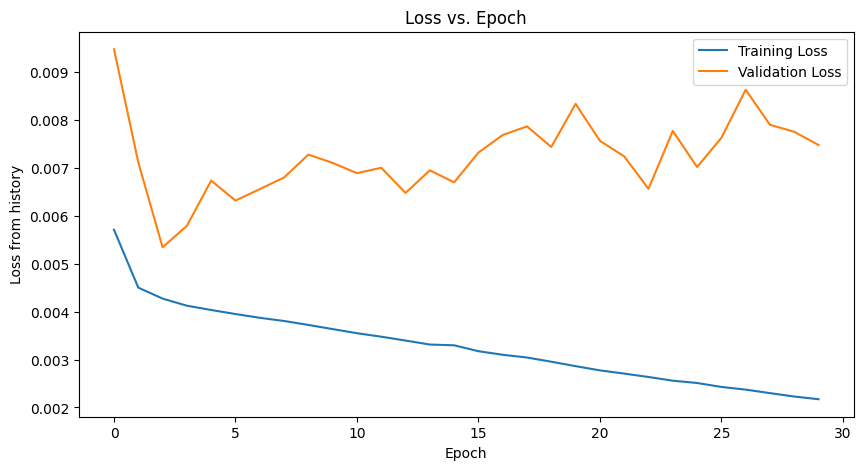

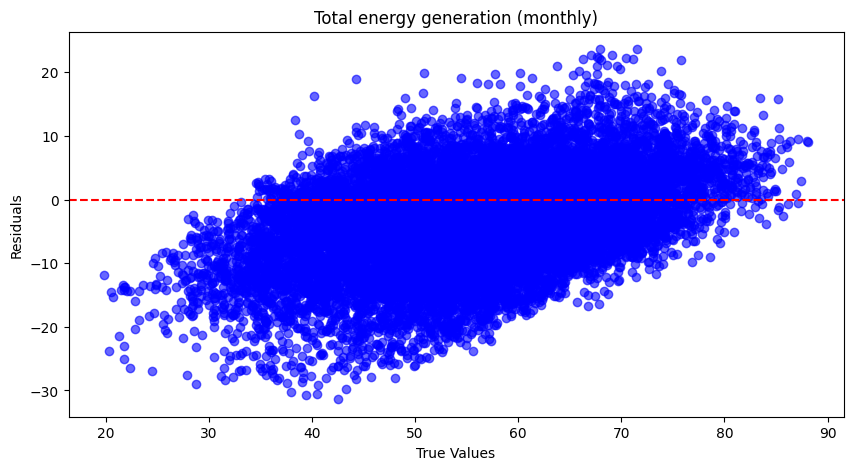

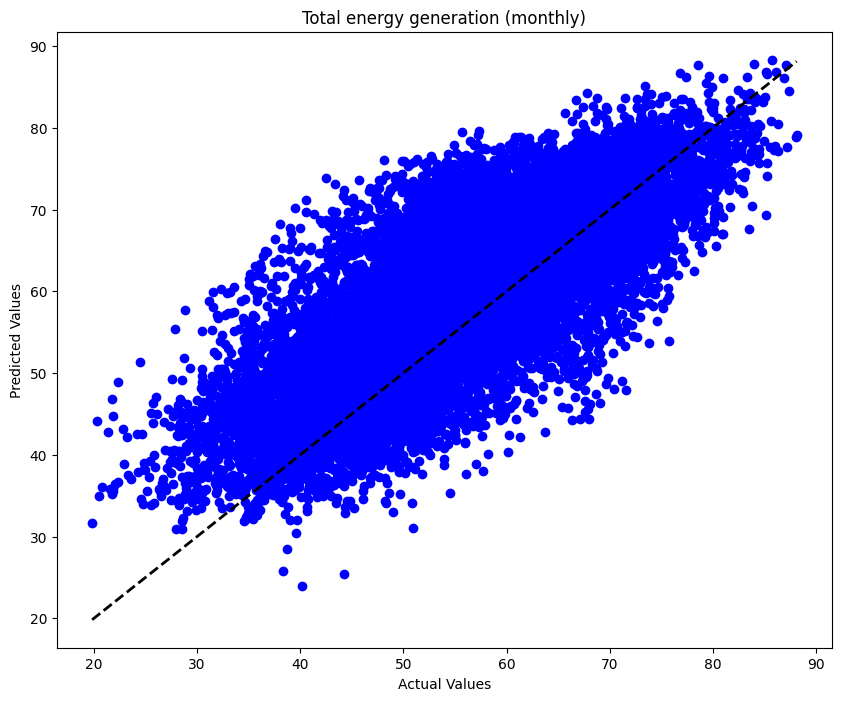

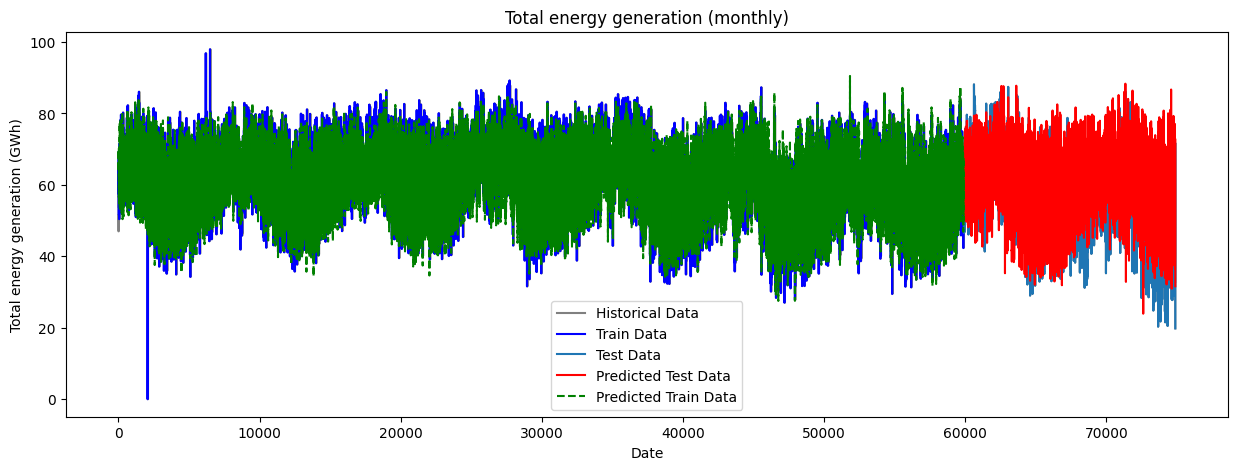

X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape = (59879, 30, 3) (14970, 30, 3) (59879, 4) (14970, 4) (74849, 30, 3) (74849,) (74879, 4)


In [1037]:
#data = data_df.copy()
target = 'Total_energy_generation_gwh'
features = ['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh']  # You can add other features if needed
result = lstm_mlvrt(target, data, features=features, lookback=30, sampling_frequency= None,
                    rolling_mean=None, detrend=False, moving_average=False, ma_window=None)

In [1078]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])
        y.append(data[i+lookback, -1])
    return np.array(X), np.array(y)

def lstm_mlvrt(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        data_df['Date'] = pd.to_datetime(data_df['Date'])
        data_df.set_index('Date', inplace=True)
        dfs_resampled = data_df[features + [target]].resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df[features + [target]]
    
    if rolling_mean:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=ma_window, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled.values)
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    # Set the train-test split to be 80-20% of the actual data without shifting
    train_size = int(len(data_scaled) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)

    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)

    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_pred_train_lstm)))
    y_pred_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_pred_test_lstm)))
    y_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_train_lstm.reshape(-1, 1))))
    y_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_test_lstm.reshape(-1, 1))))

    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1]))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1]))
    train_mse = mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mse = mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_mae = mean_absolute_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mae = mean_absolute_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_r2 = r2_score(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_r2 = r2_score(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])

    # Calculate residuals
    residuals = y_test_lstm[:, -1] - y_pred_test_lstm[:, -1]

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm[:, -1], residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm[:, -1], y_pred_test_lstm[:, -1], label='', color='blue')
    plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size]
    test_index = dfs_resampled.index[train_size:]
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm[:, -1], label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm[:, -1], label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm[:, -1], label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm[:, -1], label='Predicted Train Data', color='green', linestyle='dashed')
    # Draw a vertical line between train and test split
    plt.axvline(test_index[0], color='k', linestyle='--')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'X_test_lstm': X_test_lstm
    }


In [1080]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])
        y.append(data[i+lookback, -1])
    return np.array(X), np.array(y)

def lstm_mlvrt(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        data_df['Date'] = pd.to_datetime(data_df['Date'])
        data_df.set_index('Date', inplace=True)
        dfs_resampled = data_df[features + [target]].resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df[features + [target]]
    
    if rolling_mean:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=ma_window, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled.values)
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    # Set the train-test split to be 80-20% of the actual data without shifting
    train_size = int(len(data_scaled) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)

    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)

    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_pred_train_lstm)))
    y_pred_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_pred_test_lstm)))
    y_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_train_lstm.reshape(-1, 1))))
    y_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_test_lstm.reshape(-1, 1))))

    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1]))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1]))
    train_mse = mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mse = mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_mae = mean_absolute_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mae = mean_absolute_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_r2 = r2_score(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_r2 = r2_score(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])

    # Calculate residuals
    residuals = y_test_lstm[:, -1] - y_pred_test_lstm[:, -1]

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm[:, -1], residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm[:, -1], y_pred_test_lstm[:, -1], label='', color='blue')
    plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size]
    test_index = dfs_resampled.index[train_size: train_size + len(y_test_lstm)]
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm[:, -1], label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm[:, -1], label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm[:, -1], label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm[:, -1], label='Predicted Train Data', color='green', linestyle='dashed')
    # Draw a vertical line between train and test split
    plt.axvline(test_index[0], color='k', linestyle='--')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'X_test_lstm': X_test_lstm
    }


In [61]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])
        y.append(data[i+lookback, -1])
    return np.array(X), np.array(y)

def lstm_mlvrt(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        data_df['Date'] = pd.to_datetime(data_df['Date'])
        data_df.set_index('Date', inplace=True)
        dfs_resampled = data_df[features + [target]].resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df[features + [target]]
    
    if rolling_mean:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=ma_window, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled.values)
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    # Set the train-test split to be 80-20% of the actual data without shifting
    train_size = int(len(data_scaled) * 0.8) - lookback  # To include all data points in test
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)

    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)

    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_pred_train_lstm)))
    y_pred_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_pred_test_lstm)))
    y_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_train_lstm.reshape(-1, 1))))
    y_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_test_lstm.reshape(-1, 1))))

    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1]))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1]))
    train_mse = mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mse = mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_mae = mean_absolute_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mae = mean_absolute_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_r2 = r2_score(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_r2 = r2_score(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])

    # Calculate residuals
    residuals = y_test_lstm[:, -1] - y_pred_test_lstm[:, -1]

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm[:, -1], residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm[:, -1], y_pred_test_lstm[:, -1], label='', color='blue')
    plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:len(y_train_lstm)]
    test_index = dfs_resampled.index[len(y_train_lstm):len(y_train_lstm) + len(y_test_lstm)]
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm[:, -1], label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm[:, -1], label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm[:, -1], label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm[:, -1], label='Predicted Train Data', color='green', linestyle='dashed')
    # Draw a vertical line between train and test split
    plt.axvline(test_index[0], color='k', linestyle='--')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'X_test_lstm': X_test_lstm
    }


Epoch 1/30
11/11 [==============================] - 1s 25ms/step - loss: 0.3382 - val_loss: 0.1574
Epoch 2/30
11/11 [==============================] - 0s 8ms/step - loss: 0.2121 - val_loss: 0.0723
Epoch 3/30
11/11 [==============================] - 0s 8ms/step - loss: 0.0873 - val_loss: 0.0816
Epoch 4/30
11/11 [==============================] - 0s 11ms/step - loss: 0.0848 - val_loss: 0.0978
Epoch 5/30
11/11 [==============================] - 0s 9ms/step - loss: 0.0679 - val_loss: 0.1236
Epoch 6/30
11/11 [==============================] - 0s 9ms/step - loss: 0.0622 - val_loss: 0.1096
Epoch 7/30
11/11 [==============================] - 0s 9ms/step - loss: 0.0557 - val_loss: 0.1042
Epoch 8/30
11/11 [==============================] - 0s 10ms/step - loss: 0.0513 - val_loss: 0.0882
Epoch 9/30
11/11 [==============================] - 0s 12ms/step - loss: 0.0450 - val_loss: 0.0746
Epoch 10/30
11/11 [==============================] - 0s 11ms/step - loss: 0.0402 - val_loss: 0.0640
Epoch 11/30
11

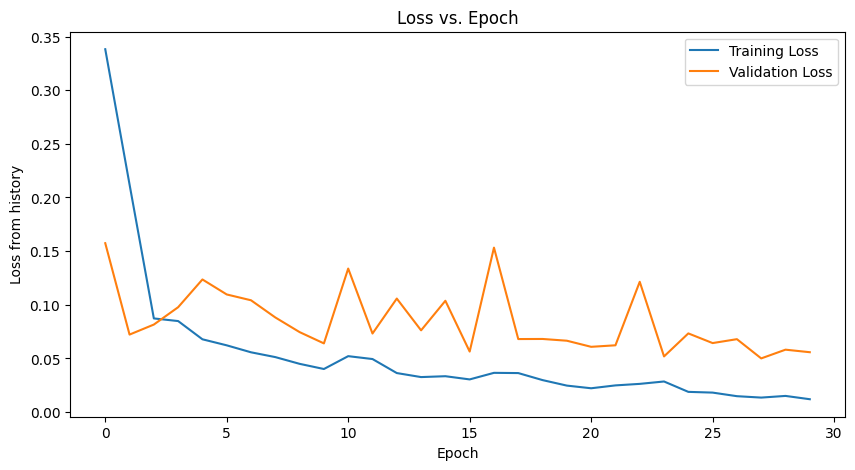

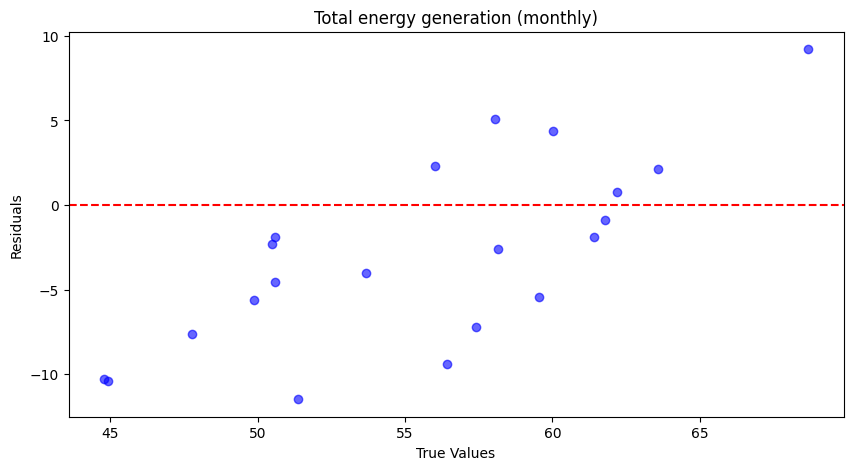

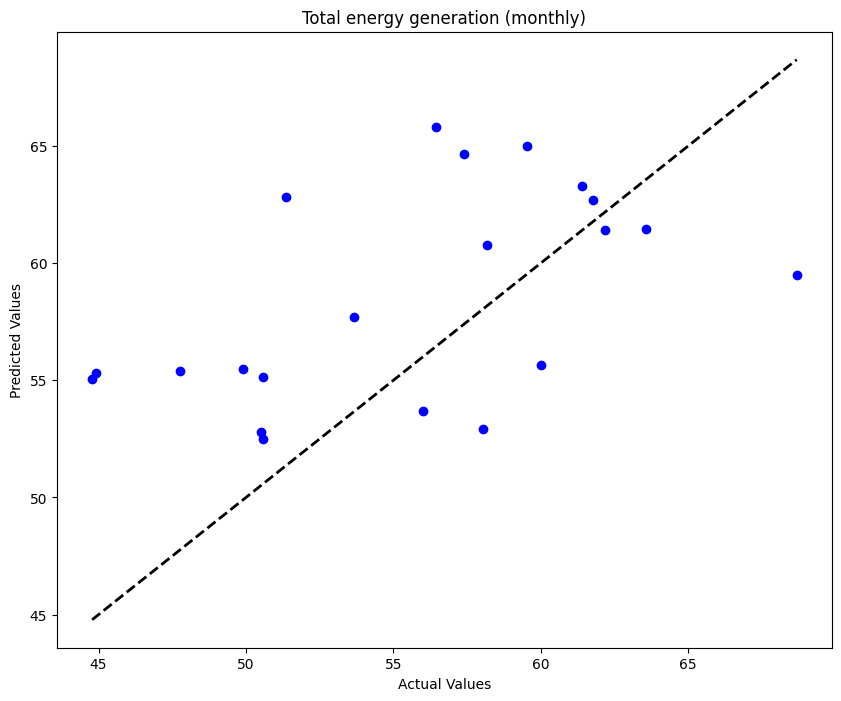

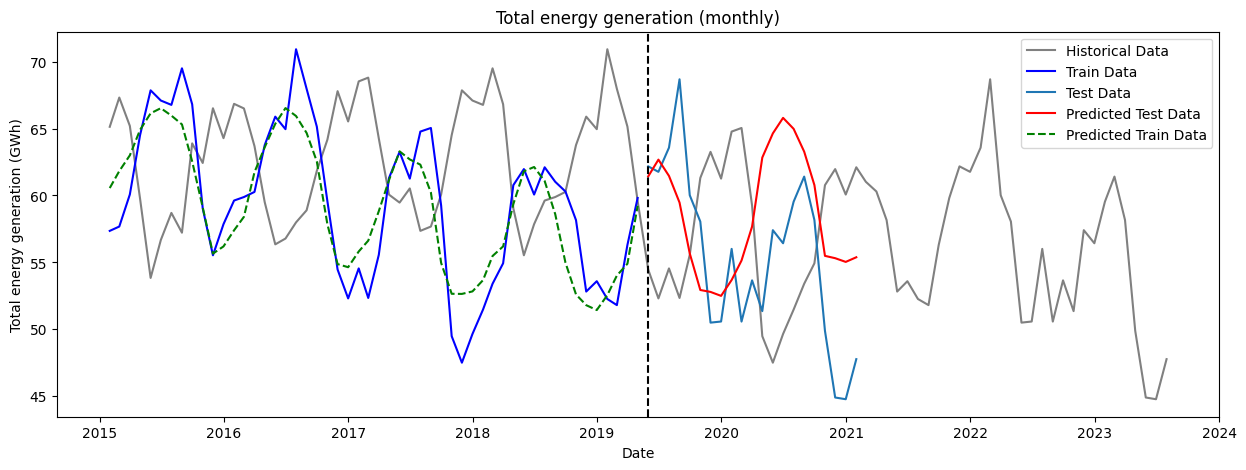

In [62]:
data = data_df.copy()
target = 'Total_energy_generation_gwh'
features = ['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh']  # You can add other features if needed
result = lstm_mlvrt(target, data, features=features, lookback=30, sampling_frequency= 'M',
                    rolling_mean=None, detrend=False, moving_average=False, ma_window=None)

In [77]:
# Data preprocessing and feature scaling
def prepare_data(dfs, features, target, lookback=12):
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)

    # Resample the data (if needed) and fill missing values
    dfs_resampled = dfs[features + [target]].resample('M').mean()
    dfs_resampled = dfs_resampled.fillna(method='bfill')

    # Apply feature scaling
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled.values)

    # Create sequences for LSTM training
    X, y = [], []
    for i in range(len(data_scaled) - lookback):
        X.append(data_scaled[i:i+lookback, :-1])
        y.append(data_scaled[i+lookback, -1])

    X_lstm, y_lstm = np.array(X), np.array(y)

    # Split the data into train and test sets
    train_size = int(len(data_scaled) * 0.8) - lookback
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

    return X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm, scaler

# Build the LSTM model
def build_lstm_model(lookback, num_features):
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, num_features), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    return model

# Train and evaluate the LSTM model
def lstm_mlvrt(target, data_df, features, lookback=12):
    # Prepare the data
    X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm, scaler = prepare_data(data_df, features, target, lookback)
    num_features = len(features)

    # Build and train the LSTM model
    model = build_lstm_model(lookback, num_features)
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)

    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)

    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_pred_train_lstm)))
    y_pred_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_pred_test_lstm)))
    y_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_train_lstm.reshape(-1, 1))))
    y_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_test_lstm.reshape(-1, 1))))

    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1]))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1]))
    train_mse = mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mse = mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_mae = mean_absolute_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mae = mean_absolute_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_r2 = r2_score(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_r2 = r2_score(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])

    # Calculate residuals
    residuals = y_test_lstm[:, -1] - y_pred_test_lstm[:, -1]

    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm[:, -1], residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(target)
    plt.show()

    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm[:, -1], y_pred_test_lstm[:, -1], label='', color='blue')
    plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(target)
    plt.show()

    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = data_df.index[:len(y_train_lstm)]
    test_index = data_df.index[len(y_train_lstm):len(y_train_lstm) + len(y_test_lstm)]
    plt.plot(data_df.index, data_df[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm[:, -1], label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm[:, -1], label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm[:, -1], label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm[:, -1], label='Predicted Train Data', color='green', linestyle='dashed')
    # Draw a vertical line between train and test split
    plt.axvline(test_index[0], color='k', linestyle='--')
    plt.legend()
    plt.title(target)
    plt.ylabel(target)
    plt.xlabel('Date')
    plt.show()

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)
    
    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'X_test_lstm': X_test_lstm
    }

Epoch 1/30
12/12 [==============================] - 1s 25ms/step - loss: 0.2294 - val_loss: 0.1233
Epoch 2/30
12/12 [==============================] - 0s 7ms/step - loss: 0.0765 - val_loss: 0.1260
Epoch 3/30
12/12 [==============================] - 0s 7ms/step - loss: 0.0669 - val_loss: 0.1328
Epoch 4/30
12/12 [==============================] - 0s 7ms/step - loss: 0.0604 - val_loss: 0.1384
Epoch 5/30
12/12 [==============================] - 0s 7ms/step - loss: 0.0510 - val_loss: 0.1243
Epoch 6/30
12/12 [==============================] - 0s 8ms/step - loss: 0.0406 - val_loss: 0.0797
Epoch 7/30
12/12 [==============================] - 0s 8ms/step - loss: 0.0379 - val_loss: 0.0690
Epoch 8/30
12/12 [==============================] - 0s 9ms/step - loss: 0.0360 - val_loss: 0.1089
Epoch 9/30
12/12 [==============================] - 0s 9ms/step - loss: 0.0276 - val_loss: 0.0764
Epoch 10/30
12/12 [==============================] - 0s 8ms/step - loss: 0.0278 - val_loss: 0.0601
Epoch 11/30
12/12 

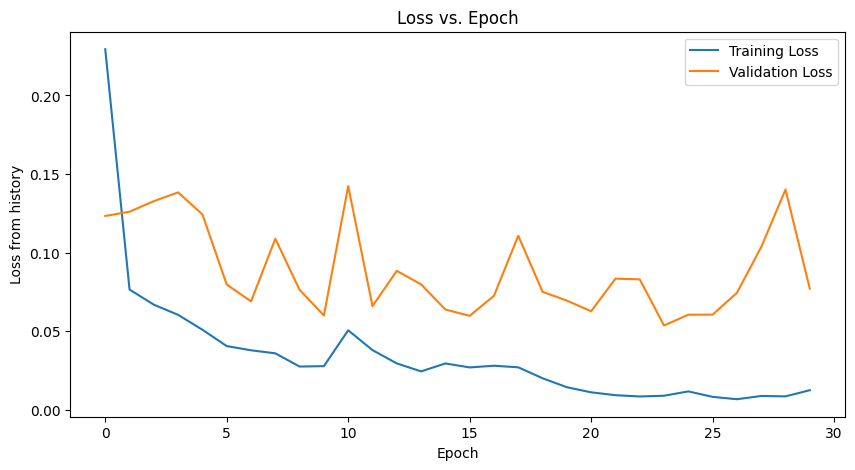

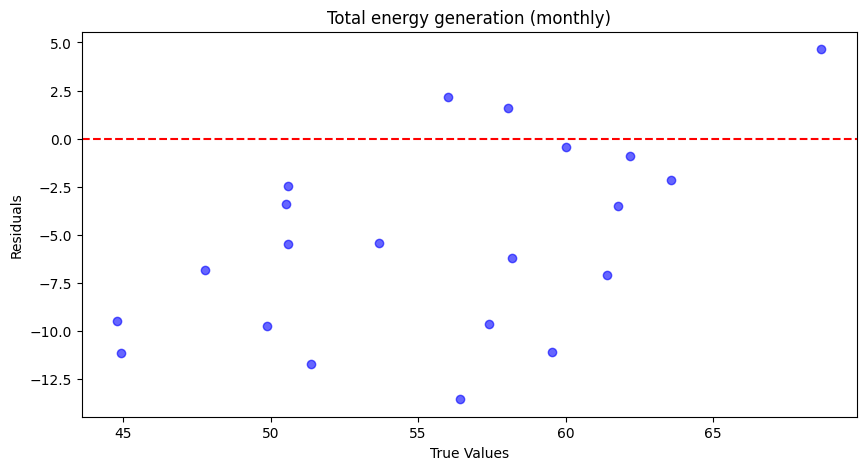

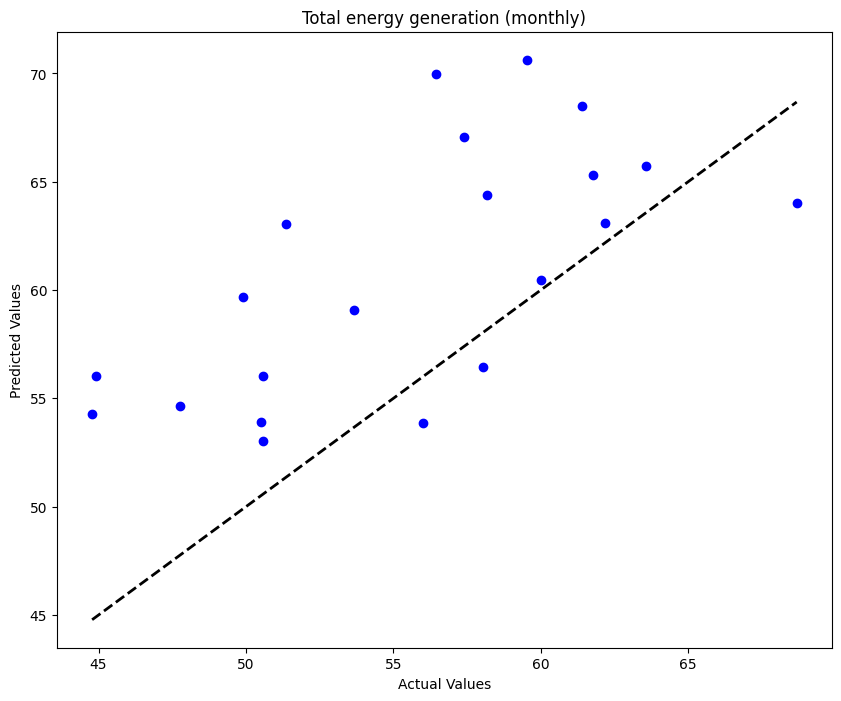

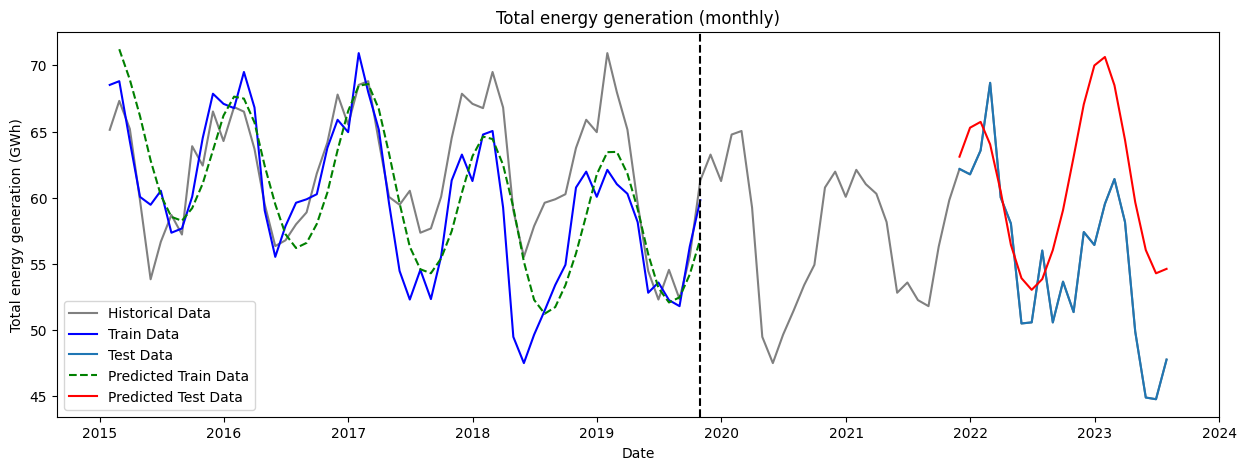

In [76]:
data = data_df.copy()
target = 'Total_energy_generation_gwh'
features = ['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh']  # You can add other features if needed
result = lstm_mlvrt(target, data, features=features, lookback=24, sampling_frequency= 'M',
                    rolling_mean=None, detrend=False, moving_average=False, ma_window=None)

In [93]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])
        y.append(data[i+lookback, -1])
    return np.array(X), np.array(y)

def lstm_mlvrt(target, data_df, features, lookback=12):
    # Prepare the input data
    target_label = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    data_df['Date'] = pd.to_datetime(data_df['Date'])
    data_df.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data_df.values)
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    # Split data into train and test sets
    X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, shuffle=False)
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)

    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)

    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_pred_train_lstm)))
    y_pred_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_pred_test_lstm)))
    y_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_train_lstm.reshape(-1, 1))))
    y_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_test_lstm.reshape(-1, 1))))

    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1]))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1]))
    train_mse = mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mse = mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_mae = mean_absolute_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mae = mean_absolute_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_r2 = r2_score(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_r2 = r2_score(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])

    # Calculate residuals
    residuals = y_test_lstm[:, -1] - y_pred_test_lstm[:, -1]

    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm[:, -1], residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(target_label)
    plt.show()

    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm[:, -1], y_pred_test_lstm[:, -1], label='', color='blue')
    plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(target_label)
    plt.show()

    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = data_df.index[:len(y_train_lstm)]
    test_index = data_df.index[len(y_train_lstm):len(y_train_lstm) + len(y_test_lstm)]
    plt.plot(data_df.index, data_df[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm[:, -1], label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm[:, -1], label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm[:, -1], label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm[:, -1], label='Predicted Train Data', color='green', linestyle='dashed')
    # Draw a vertical line between train and test split
    plt.axvline(test_index[0], color='k', linestyle='--')
    plt.legend()
    plt.title(target_label)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)
    
    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'y_train_lstm': y_train_lstm,
        'X_test_lstm': X_test_lstm,
        'y_test_lstm': y_test_lstm
    }


In [104]:
columns_to_keep= ['Date', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh', 'Total_energy_generation_gwh']

data_mlvt = data_df[columns_to_keep].copy()
data_mlvt.head()

,Date,Solar_gwh,Wind_onshore_gwh,Wind_offshore_gwh,Total_energy_generation_gwh
0,2015-01-01,0.0,8.84975,0.52100,51.45925
1,2015-01-01,0.0,9.04650,0.52075,49.98825
2,2015-01-01,0.0,9.19600,0.51900,49.26525
3,2015-01-01,0.0,9.14675,0.52250,48.53800
4,2015-01-01,0.0,9.20400,0.52425,48.63000


In [102]:
#data = data_mlvt.copy()
#data.head()

Epoch 1/30
11979/11979 [==============================] - 46s 4ms/step - loss: 0.0064 - val_loss: 0.0075
Epoch 2/30
11979/11979 [==============================] - 45s 4ms/step - loss: 0.0051 - val_loss: 0.0059
Epoch 3/30
11979/11979 [==============================] - 46s 4ms/step - loss: 0.0049 - val_loss: 0.0068
Epoch 4/30
11979/11979 [==============================] - 47s 4ms/step - loss: 0.0048 - val_loss: 0.0076
Epoch 5/30
11979/11979 [==============================] - 45s 4ms/step - loss: 0.0047 - val_loss: 0.0079
Epoch 6/30
11979/11979 [==============================] - 44s 4ms/step - loss: 0.0047 - val_loss: 0.0071
Epoch 7/30
11979/11979 [==============================] - 45s 4ms/step - loss: 0.0046 - val_loss: 0.0075
Epoch 8/30
11979/11979 [==============================] - 46s 4ms/step - loss: 0.0046 - val_loss: 0.0071
Epoch 9/30
11979/11979 [==============================] - 45s 4ms/step - loss: 0.0045 - val_loss: 0.0070
Epoch 10/30
11979/11979 [==============================

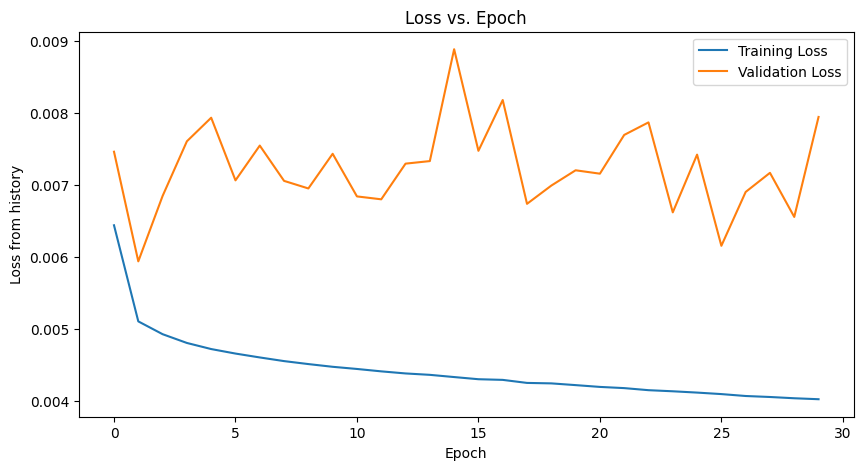

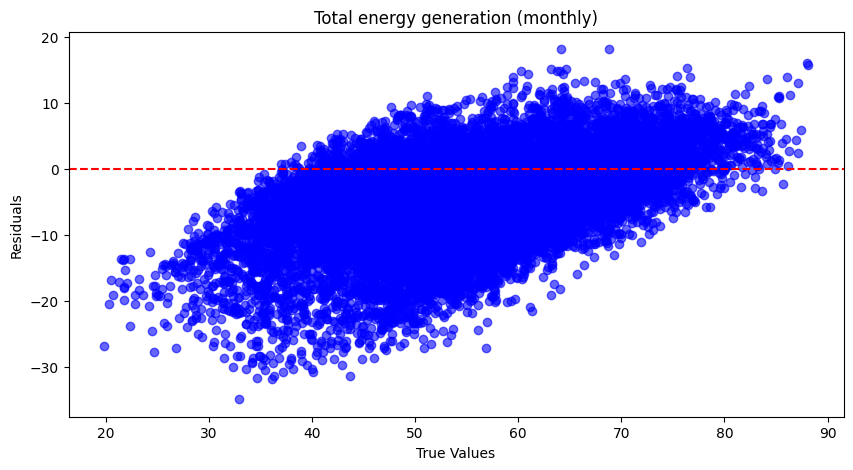

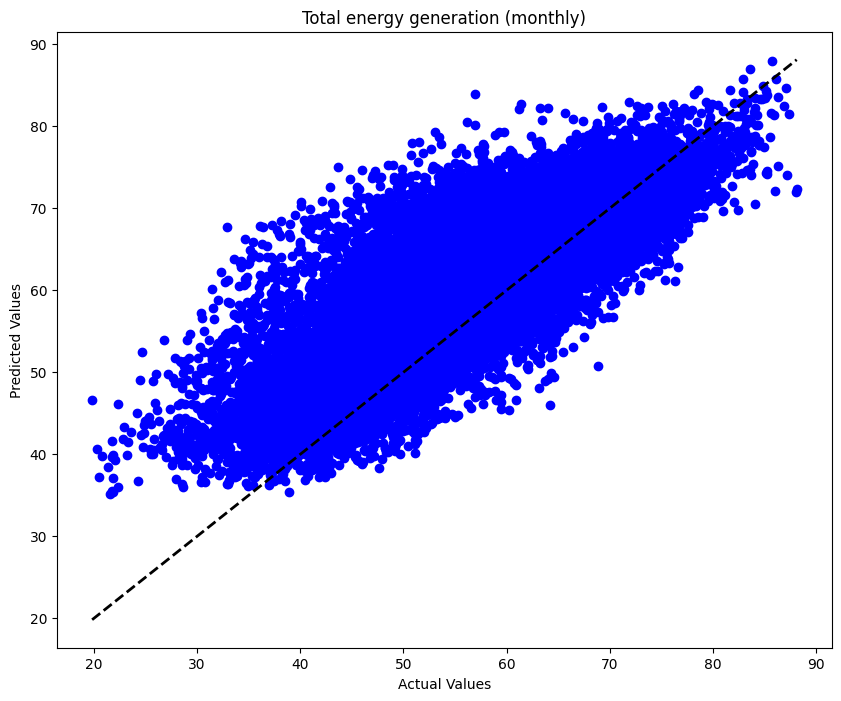

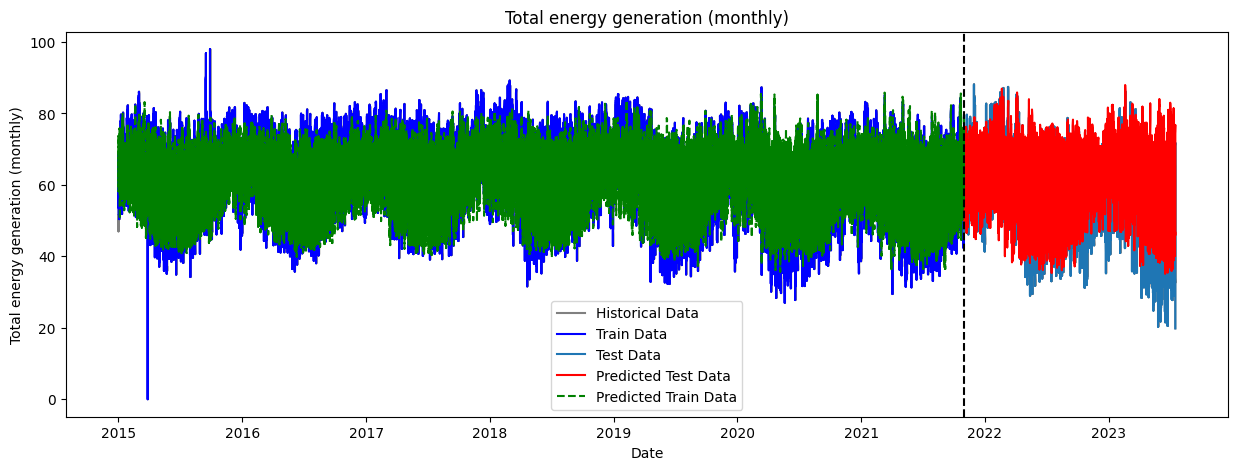

Train RMSE: 6.1395947831158155
Train MSE: 37.69462410086294
Train MAE: 4.910259363680527
Train R2 Score: 0.6680912525267234
Test RMSE: 8.732041497764298
Test MSE: 76.24854871867775
Test MAE: 6.84926870883093
Test R2 Score: 0.4049778173071815


In [105]:
data = data_mlvt.copy()
target = 'Total_energy_generation_gwh'
features = ['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh']  # You can add other features if needed
result = lstm_mlvrt(target, data, features=features, lookback=12)
#result = build_lstm_model(target, data, features=features, lookback=24, sampling_frequency= 'M',
#                    rolling_mean=None, detrend=False, moving_average=False, ma_window=None)

In [1023]:
data = data_df.copy()

In [1038]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [776]:
df_dt.columns, dfs.columns

(Index(['Total_energy_generation_gwh'], dtype='object'),
 Index(['Date', 'Total_energy_generation_gwh'], dtype='object'))

In [777]:
#df_dt, dfs

In [778]:
# Resample 'Solar_gwh' at a monthly frequency and aggregate using mean
dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs.set_index('Date', inplace=True)
dfs_monthly =   dfs.resample('M').mean()
#dft_monthly =  df_dt.resample('M').mean()

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_67547/1402019342.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


In [779]:
print(dfs.shape, dfs_monthly.shape)

(74879, 1) (103, 1)


In [780]:

dfs = data_df[['Date', target]]


# Resample 'Solar_gwh' at a monthly frequency and aggregate using mean
dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs.set_index('Date', inplace=True)
dfs_monthly =   dfs.resample('M').mean()
#dft_monthly =  df_dt.resample('M').mean()




/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_67547/3237135837.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


In [781]:
lookback =4
test_data = dfs_monthly.tail(100)
training_data =dfs_monthly.iloc[:,0:1]
training_data = training_data[:-lookback]

In [782]:
#print(training_data.values, training_data.index)
training_data  = training_data.values
scaler = MinMaxScaler()
train = scaler.fit_transform(training_data)


In [783]:
X_train = []
y_train = []
#Range should be 60 values to end
for  i in range (lookback, train.shape[0]):
    #  X_train 0-59
    X_train.append(train[i-lookback:i])
    # y should be 60 value based on past lookback values
    y_train.append(train[i])
# Convert int Numpy Array
X_train = np.array(X_train)
y_train = np.array(y_train)
print(X_train.shape, y_train.shape)



(95, 4, 1) (95, 1)


In [784]:
# shape should be the number of [Datapoints, Steps, 1]#
# we convert into 3-d Vector or #rd Dimensions
X_train = np.reshape(X_train, newshape=(X_train.shape[0], X_train.shape[1],1))
X_train.shape

(95, 4, 1)

In [785]:
# LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape= (X_train.shape[1],1)))  # First LSTM layer
model.add(Dropout(0.2))

# Adding a second LSTM layer and some Dropout regularization
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Adding a third LSTM layer and some Dropout regularization
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))


# Adding a fourth LSTM layer and some Dropout regularization
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Adding the output layer
model.add(Dense(units=1))

#compiling the run
model.compile(loss='mse', optimizer='adam')
#history = model.fit(X_train, y_train epochs=100, batch_size=30, validation_data=(X_test, y_test), verbose=1)
history = model.fit(X_train, y_train, epochs=100, batch_size=30, verbose=1)

# Access training and validation loss from history object
train_loss = history.history['loss']
#val_loss = history.history['val_loss']

Epoch 1/100
4/4 [==============================] - 3s 8ms/step - loss: 0.3139
Epoch 2/100
4/4 [==============================] - 0s 5ms/step - loss: 0.2633
Epoch 3/100
4/4 [==============================] - 0s 5ms/step - loss: 0.1996
Epoch 4/100
4/4 [==============================] - 0s 5ms/step - loss: 0.1177
Epoch 5/100
4/4 [==============================] - 0s 5ms/step - loss: 0.0599
Epoch 6/100
4/4 [==============================] - 0s 5ms/step - loss: 0.0816
Epoch 7/100
4/4 [==============================] - 0s 5ms/step - loss: 0.0636
Epoch 8/100
4/4 [==============================] - 0s 4ms/step - loss: 0.0539
Epoch 9/100
4/4 [==============================] - 0s 4ms/step - loss: 0.0544
Epoch 10/100
4/4 [==============================] - 0s 4ms/step - loss: 0.0584
Epoch 11/100
4/4 [==============================] - 0s 4ms/step - loss: 0.0555
Epoch 12/100
4/4 [==============================] - 0s 4ms/step - loss: 0.0544
Epoch 13/100
4/4 [==============================] - 0s 4ms/st

#### Test Data

In [786]:
#dfs_monthly.tail(10),test_data.tail(10)#test_data.head()

In [787]:
test_data.shape, dfs_monthly.shape

((100, 1), (103, 1))

In [788]:
df_Total = pd.concat((dfs_monthly[target] ,test_data[target]), axis=0)

In [789]:
df_Total.shape, dfs.shape

((203,), (74879, 1))

In [818]:
inputs = df_Total[len(df_Total) - len(test_data) -lookback:].values

# We need to Reshape
inputs = inputs.reshape(-1,1)

# Normalize the Dataset
inputs = scaler.transform(inputs)


inputs = df_Total[len(df_Total) - len(test_data) - lookback:].values
#print('inputs=', inputs)

# Reshape inputs to a 2D array
inputs = inputs.reshape(-1,1)

# Normalize the Datasets
inputs = scaler.transform(inputs)

inputs = df_Total[len(df_Total) - len(test_data) - lookback:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(len(test_data) - lookback + 1):  # Ensure we take complete sequences
    X_test.append(inputs[i:i + lookback])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# LSTM prediction on test data
y_pred_test = model.predict(X_test)

# Do inverse transformation to get the predicted value
#y_pred_test = scaler.inverse_transform(y_pred_test)

#X_test = []
#for i in range(lookback, len(df_Total)):
#X_test.append(inputs[i - lookback:i])

# Convert into Numpy Array and stack vertically
#X_test = np.array(X_test)

# Reshape before passing to Network
#X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Pass to the model

# LSTM prediction on test and train data
#y_pred_test = model.predict(X_test)

# Do inverse Transformation to get the predicted value
#y_pred_test = scaler.inverse_transform(y_pred_test)

y_pred_test_list =y_pred_test
actual_val = test_data[target].to_list()
pred_val = y_pred_test_list
times = test_data.index.to_list()
#print('actual_val=',actual_val)
#print('pred_val=',pred_val)

ML_df = pd.DataFrame(data={
    "Dates":times,
    "testval": actual_val,
 #  "predval":[x[0] for x in pred_val]
})
ML_df.head(), ML_df.shape, X_test.shape

1/1 [==============================] - 0s 28ms/step


(       Dates    testval
 0 2021-12-31  61.767321
 1 2022-01-31  63.572379
 2 2022-02-28  68.679237
 3 2022-03-31  60.019961
 4 2022-04-30  58.052026,
 (20, 2),
 (9, 12, 1))

In [796]:
# Extract relevant data columns and resample to monthly frequency
dfs = data_df[['Date', target]]
dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs.set_index('Date', inplace=True)
dfs_monthly = dfs.resample('M').mean()

lookback = 4

test_data = dfs_monthly.tail(100)
# Prepare training data
training_data = dfs_monthly.iloc[:, 0:1]
training_data = training_data[:-lookback]
training_data = training_data.values
scaler = MinMaxScaler()
train = scaler.fit_transform(training_data)

X_train = []
y_train = []

for i in range(lookback, train.shape[0]):
    X_train.append(train[i-lookback:i])
    y_train.append(train[i])

X_train = np.array(X_train)
y_train = np.array(y_train)
print(X_train.shape, y_train.shape)

X_train = np.reshape(X_train, newshape=(X_train.shape[0], X_train.shape[1], 1))

# LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))  # First LSTM layer
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))  # Second LSTM layer
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))  # Third LSTM layer
model.add(Dropout(0.2))

model.add(LSTM(units=50))  # Fourth LSTM layer
model.add(Dropout(0.2))

model.add(Dense(units=1))  # Output layer

# Compile the model
model.compile(loss='mse', optimizer='adam')

# Fit the model
history = model.fit(X_train, y_train, epochs=100, batch_size=30, verbose=1)

# Assuming you have defined 'test_data' and 'scaler' variables

df_Total = pd.concat((dfs_monthly[target], test_data[target]), axis=0)

# Prepare test data for prediction
inputs = df_Total[len(df_Total) - len(test_data) - lookback:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(len(test_data) - lookback + 1):  # Ensure we take complete sequences
    X_test.append(inputs[i:i + lookback])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# LSTM prediction on test data
y_pred_test = model.predict(X_test)

# Do inverse transformation to get the predicted value
y_pred_test = scaler.inverse_transform(y_pred_test)

y_pred_test_list = y_pred_test

actual_val = test_data[target].to_list()
pred_val = [x[0] for x in y_pred_test_list ]
times = test_data.index.to_list()
print('actual_val=',actual_val)
print('pred_val=',pred_val)


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_67547/266451931.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


(95, 4, 1) (95, 1)
Epoch 1/100
4/4 [==============================] - 4s 7ms/step - loss: 0.3175
Epoch 2/100
4/4 [==============================] - 0s 5ms/step - loss: 0.2756
Epoch 3/100
4/4 [==============================] - 0s 5ms/step - loss: 0.2211
Epoch 4/100
4/4 [==============================] - 0s 5ms/step - loss: 0.1520
Epoch 5/100
4/4 [==============================] - 0s 5ms/step - loss: 0.0813
Epoch 6/100
4/4 [==============================] - 0s 5ms/step - loss: 0.0654
Epoch 7/100
4/4 [==============================] - 0s 4ms/step - loss: 0.0817
Epoch 8/100
4/4 [==============================] - 0s 5ms/step - loss: 0.0547
Epoch 9/100
4/4 [==============================] - 0s 4ms/step - loss: 0.0585
Epoch 10/100
4/4 [==============================] - 0s 5ms/step - loss: 0.0619
Epoch 11/100
4/4 [==============================] - 0s 5ms/step - loss: 0.0583
Epoch 12/100
4/4 [==============================] - 0s 4ms/step - loss: 0.0531
Epoch 13/100
4/4 [========================

In [792]:

actual_val = test_data[target].to_list()
pred_val = [x[0] for x in y_pred_test_list ]
times = test_data.index.to_list()
print('actual_val=',actual_val)
print('pred_val=',pred_val)

actual_val= [59.76833645833334, 53.8420120967742, 56.67736458333333, 58.69925470430107, 57.22197076612903, 63.89307604166667, 62.42927348993288, 66.51508125000001, 64.28230779569893, 66.84643178763442, 66.502533045977, 63.68589434724092, 59.50559583333334, 56.35039952956989, 56.784540625000005, 57.99277788978495, 58.895302083333334, 61.839152777777784, 64.1654154362416, 67.7925625, 65.53014280913978, 68.52240725806452, 68.80404315476191, 64.26132772543741, 60.06284861111111, 59.47011592741936, 60.52734791666666, 57.358163642473116, 57.68083467741935, 60.07485972222222, 64.5093687919463, 67.85483333333333, 67.09321303763441, 66.76801948924731, 69.4990197172619, 66.81475572005384, 59.039887847222225, 55.53537768817204, 57.85958611111111, 59.62255477150538, 59.8847872983871, 60.26785659722222, 63.76343993288591, 65.88900902777777, 64.95363037634408, 70.92557829301076, 67.96930245535714, 65.14550100942127, 59.584409722222226, 54.47017842741935, 52.31261458333333, 54.55383266129032, 52.3462

In [ ]:
#print(actual_val.shape, pred_val.shape)

ValueError: x and y must have same first dimension, but have shapes (100,) and (97, 1)

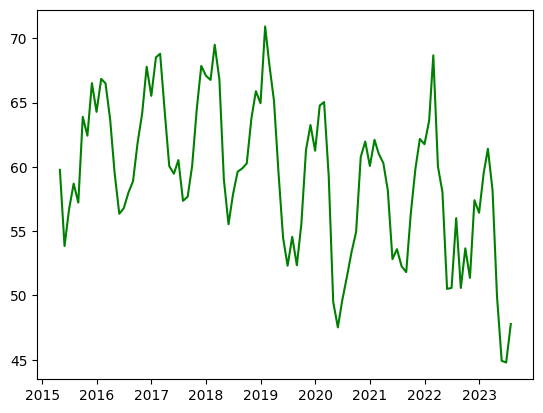

In [794]:
fig = plt.figure()

ax1= fig.add_subplot(111)

x =times
y = actual_val
y1 = y_pred_test_list#pred_val

plt.plot(x,y, color="green")
plt.plot(x,y1, color="red")
# beautify the x-labels
plt.gcf().autofmt_xdate()
plt.xlabel('Dates')
plt.ylabel("Power in MW")
plt.title("Machine Learned the Pattern Predicting Future Values ")
plt.legend()

In [697]:



ML_df = pd.DataFrame(data={
    "Dates":times,
    "testval": actual_val,
    "predval":[x[0] for x in pred_val]
})


IndexError: invalid index to scalar variable.

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_67547/2771078739.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


(79, 12, 1) (79, 1)
Epoch 1/100
3/3 [==============================] - 3s 14ms/step - loss: 0.3148
Epoch 2/100
3/3 [==============================] - 0s 13ms/step - loss: 0.1884
Epoch 3/100
3/3 [==============================] - 0s 13ms/step - loss: 0.0813
Epoch 4/100
3/3 [==============================] - 0s 12ms/step - loss: 0.0901
Epoch 5/100
3/3 [==============================] - 0s 11ms/step - loss: 0.0682
Epoch 6/100
3/3 [==============================] - 0s 11ms/step - loss: 0.0586
Epoch 7/100
3/3 [==============================] - 0s 11ms/step - loss: 0.0624
Epoch 8/100
3/3 [==============================] - 0s 11ms/step - loss: 0.0600
Epoch 9/100
3/3 [==============================] - 0s 11ms/step - loss: 0.0497
Epoch 10/100
3/3 [==============================] - 0s 11ms/step - loss: 0.0534
Epoch 11/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0472
Epoch 12/100
3/3 [==============================] - 0s 11ms/step - loss: 0.0524
Epoch 13/100
3/3 [===========

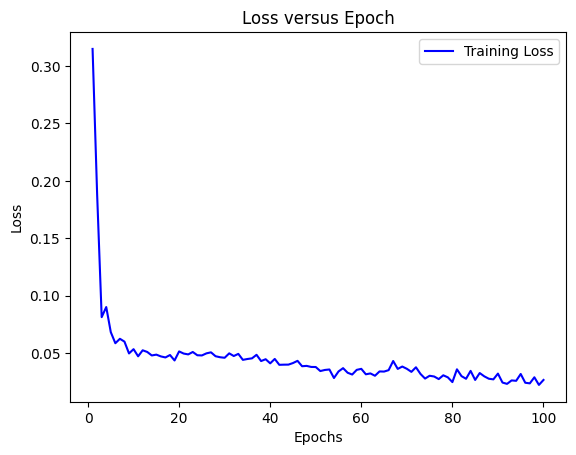

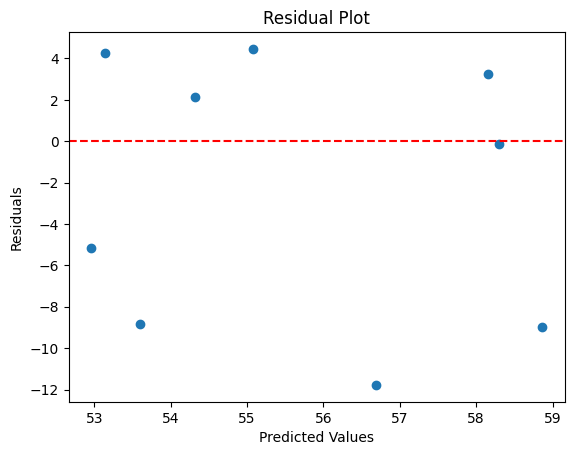

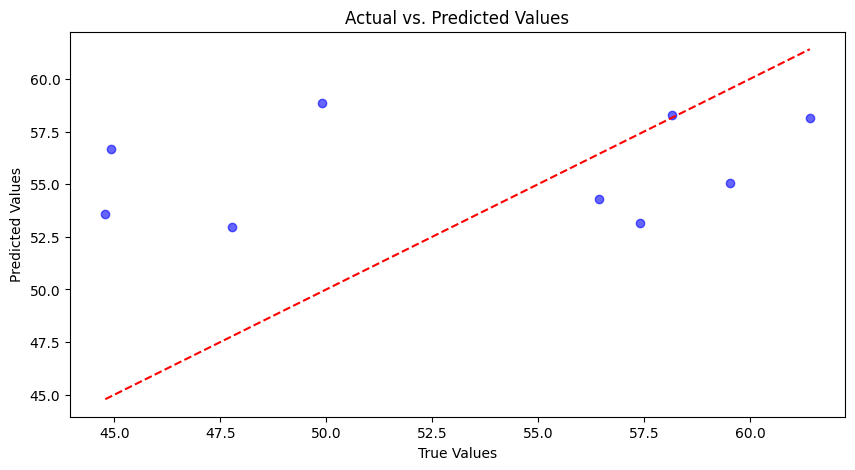

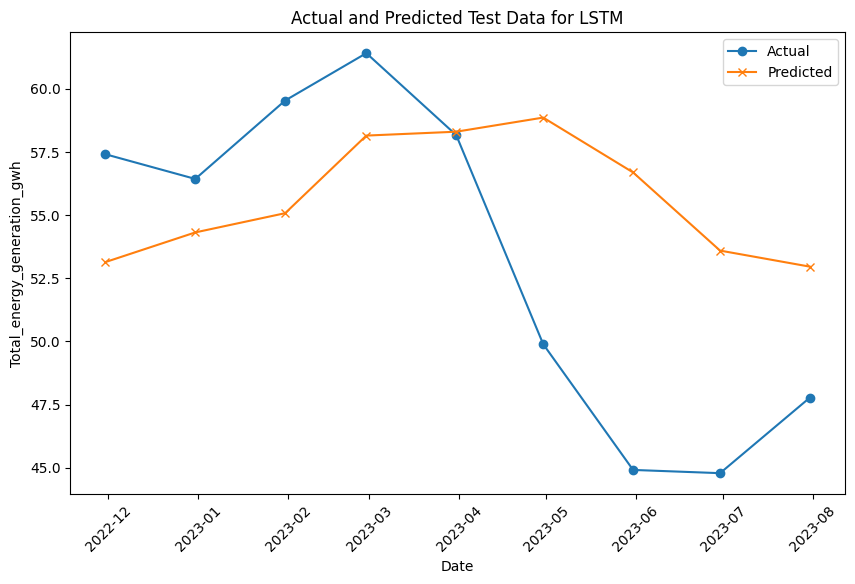

In [812]:

# Extract relevant data columns and resample to monthly frequency
dfs = data_df[['Date', target]]
dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs.set_index('Date', inplace=True)
dfs_monthly = dfs.resample('M').mean()

lookback = 12


test_data = dfs_monthly.tail(20)

# Prepare training data
training_data = dfs_monthly.iloc[:, 0:1]
training_data = training_data[:-lookback]
training_data = training_data.values
scaler = MinMaxScaler()
train = scaler.fit_transform(training_data)

X_train = []
y_train = []

for i in range(lookback, train.shape[0]):
    X_train.append(train[i-lookback:i])
    y_train.append(train[i])

X_train = np.array(X_train)
y_train = np.array(y_train)
print(X_train.shape, y_train.shape)

X_train = np.reshape(X_train, newshape=(X_train.shape[0], X_train.shape[1], 1))

# LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))  # First LSTM layer
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))  # Second LSTM layer
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))  # Third LSTM layer
model.add(Dropout(0.2))

model.add(LSTM(units=50))  # Fourth LSTM layer
model.add(Dropout(0.2))

model.add(Dense(units=1))  # Output layer

# Compile the model
model.compile(loss='mse', optimizer='adam')

# Fit the model
history = model.fit(X_train, y_train, epochs=100, batch_size=30, verbose=1)

# Assuming you have defined 'test_data' and 'scaler' variables

df_Total = pd.concat((dfs_monthly[target], test_data[target]), axis=0)

# Prepare test data for prediction
inputs = df_Total[len(df_Total) - len(test_data) - lookback:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(len(test_data) - lookback + 1):  # Ensure we take complete sequences
    X_test.append(inputs[i:i + lookback])

# LSTM prediction on test data
y_pred_test = model.predict(np.array(X_test))

# Inverse transform y_pred_test to the original scale
y_pred_test = scaler.inverse_transform(y_pred_test)

# Flatten the arrays for consistent shapes
y_pred_test = y_pred_test.flatten()
actual_val = np.array(test_data[target].iloc[-len(y_pred_test):])  # Adjusting the number of samples to match

# Calculate loss versus epoch
loss_history = history.history['loss']
epochs = range(1, len(loss_history) + 1)

# Print evaluation metrics
rmse = np.sqrt(mean_squared_error(actual_val, y_pred_test))
mae = mean_absolute_error(actual_val, y_pred_test)
mse = mean_squared_error(actual_val, y_pred_test)
r2 = r2_score(actual_val, y_pred_test)

print("RMSE:", rmse)
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

# Plot loss versus epoch
plt.plot(epochs, loss_history, 'b', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss versus Epoch')
plt.legend()
plt.show()


# Create a residual plot
residuals = actual_val - y_pred_test
plt.scatter(y_pred_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


plt.figure(figsize=(10, 5))
plt.scatter(actual_val, y_pred_test, color='blue', alpha=0.6)
plt.plot([min(actual_val), max(actual_val)], [min(actual_val), max(actual_val)], 'r--')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

# Plot actual and predicted test data for LSTM
plt.figure(figsize=(10, 6))
plt.plot(test_data.index[-len(y_pred_test):], actual_val, label='Actual', marker='o')
plt.plot(test_data.index[-len(y_pred_test):], y_pred_test, label='Predicted', marker='x')
plt.xlabel('Date')
plt.ylabel(target)
plt.title('Actual and Predicted Test Data for LSTM')
plt.legend()
plt.xticks(rotation=45)
plt.show()
